# Fake News Detection with Graph Neural Networks
Date: 2026

**Kurzbeschreibung**:  
Dieses Notebook behandelt ausschliesslich die **Explorative Datenanalyse** auf unprocessed Datensätzen.  

**Quellen**:
* https://distill.pub/2021/gnn-intro/



**Datensätze**:  
Die Daten stammen aus folgendem Repository `https://github.com/safe-graph/GNN-FakeNews?tab=readme-ov-file`   
Der Datensatz umfasst Netzwerke zur Verbreitung gefälschter und echter Nachrichten auf Twitter, die auf der Grundlage von Faktenprüfungen von Politifact und Gossipcop erstellt wurden. Die Grafiken zu den Retweets von Nachrichten wurden ursprünglich von FakeNewsNet extrahiert.

`/data/raw/`:  
| Datei                        | Inhalt                                                      | Erklärung                                                              |
| ---------------------------- | ----------------------------------------------------------- | ---------------------------------------------------------------------- |
| `gos_id_time_mapping.pkl`    | Dictionary: `{news_id: [timestamps]}`                       | Gibt an, wann ein bestimmter Gossip-Artikel auf Twitter erwähnt wurde. |
| `gos_id_twitter_mapping.pkl` | Dictionary: `{news_id: [user_ids]}`                         | Enthält die Twitter-User, die den Artikel geteilt oder erwähnt haben.  |
| `gos_news_list.txt`          | Textdatei mit IDs               | Eventuell nützlich um mit original content aus FakeNewsNet zu mergen                   |
| `pol_id_time_mapping.pkl`    | Wie oben, aber für Politifact-Daten.                        |                                                                        |
| `pol_id_twitter_mapping.pkl` | Wie oben, aber für Politifact-Daten.                        |                                                                        |
| `pol_news_list.txt`          | Liste der Politifact-Newsartikel.                           |                                                                        |
| `gossipcop/` & `politifact/` | Enthalten jeweils die zugehörigen Graphdaten (siehe unten). |                                                                        |
    

`gossipcop/ & politifact/`:  
| Datei                                          | Typ           | Beschreibung                                                                                                                 |
| ---------------------------------------------- | ------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| `A.txt`                                        | Textdatei     | Enthält die Adjazenzmatrix (Graphstruktur). Jede Zeile ist eine Kante zwischen zwei Knoten (z. B. User–User oder User–News). |
| `graph_labels.npy`                             | NumPy-Array   | Label für jeden Graph (z. B. 0 = echte News, 1 = Fake News).                                                                 |
| `node_graph_id.npy`                            | NumPy-Array   | Ordnet jeden Knoten einem bestimmten Graph zu (welche Nodes gehören zu welchem News-Artikel).                                |
| `new_bert_feature.npz`                         | Sparse-Matrix | Feature-Matrix der Knoten basierend auf **BERT**-Embeddings (sprachliche Repräsentationen).    (node- embeddings)                              |
| `new_content_feature.npz`                      | Sparse-Matrix | Features aus dem Textinhalt (z. B. TF-IDF oder Bag-of-Words).                                                                |
| `new_profile_feature.npz`                      | Sparse-Matrix | Twitter-User-Metadaten (z. B. Follower, Verifikationsstatus).                                                                |
| `new_spacy_feature.npz`                        | Sparse-Matrix | Features aus linguistischer Verarbeitung mit SpaCy.                                                                          |
| `train_idx.npy`, `val_idx.npy`, `test_idx.npy` | NumPy-Arrays  | Indizes zur Aufteilung der Graphs in Trainings-, Validierungs- und Testset.                                                  |


**Graph Netzwerk Begriffe:**  

* **Node/Knoten**: Einheiten/Akteure im Netzwerk -> Twitter-User / Twitter-Nachricht
* **Edge/Kante**: Verbindung zwischen Nodes/Knoten -> Interaktion/Beziehung
* **Degree/Grad**: Anzahl Verbindungen(Edges/Kanten) die ein Node/Knoten hat

In [ ]:
#!jupyter nbconvert --to html EDA_gossip_politic.ipynb

**Libraries:**

In [2]:
from pathlib import Path
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import matplotlib.patches as mpatches
import scipy.sparse as sp
import numpy as np
import re

from tqdm import tqdm
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from IPython.display import display

data_path = Path("../data/raw").expanduser().resolve()
print("Data directory:", data_path)

Data directory: <local-path> SEM\KOMP\fraud_detection\CGML-5Da\data\raw


In [3]:
pd.set_option('display.max_columns', None)     # Alle Spalten anzeigen
pd.set_option('display.max_rows', None)          # Max. Zeilen anzeigen
pd.set_option('display.max_colwidth', 100)     # Längere Textfelder sichtbar machen
pd.set_option('display.width', 1000)           # Gesamtbreite der Ausgabe

In [4]:
def load_pickle(path: Path):
    with path.open("rb") as f:
        try:
            return pickle.load(f)
        except Exception:
            return pickle.load(f, encoding="latin1")

def load_news_list(path: Path):
    with path.open("r", encoding="utf-8", errors="replace") as f:
        return [line.strip() for line in f if line.strip()]

# In DF umwandeln
def mapping_to_df(mapping, colname):
    """Wandelt ein Dictionary {news_id: [values]} in einen DataFrame um."""
    df = pd.DataFrame([
        {
            "news_id": k,
            colname: v if isinstance(v, (list, tuple)) else [v]
        }
        for k, v in mapping.items()
    ])
    return df

#-----------------------------------------

gos_id_time = load_pickle(data_path / "gos_id_time_mapping.pkl")
gos_id_twitter = load_pickle(data_path / "gos_id_twitter_mapping.pkl")
gos_news = load_news_list(data_path / "gos_news_list.txt")


gos_time_df = mapping_to_df(gos_id_time, "timestamps")
gos_twitter_df = mapping_to_df(gos_id_twitter, "user_ids")


In [5]:
print(gos_time_df.head(3))
print(gos_twitter_df.head(3))
print(gos_news[:3])

   news_id    timestamps
0        0            []
1        1  [1528805290]
2        2  [1528805421]
   news_id            user_ids
0        0  [gossipcop-943234]
1        1         [199874723]
2        2        [2471499625]
['gossipcop-943234', 'gossipcop-905156', 'gossipcop-924455']


In [6]:
# Political news
pol_id_time = load_pickle(data_path / "pol_id_time_mapping.pkl")
pol_id_twitter = load_pickle(data_path / "pol_id_twitter_mapping.pkl")
pol_news = load_news_list(data_path / "pol_news_list.txt")

pol_time_df = mapping_to_df(pol_id_time, "timestamps")
pol_twitter_df = mapping_to_df(pol_id_twitter, "user_ids")


print(pol_time_df.head(3))
print(pol_twitter_df.head(3))
print(pol_news[:3])

   news_id    timestamps
0        0            []
1        1  [1231344102]
2        2  [1231344109]
   news_id          user_ids
0        0  [politifact4190]
1        1        [14200465]
2        2        [18244561]
['politifact4190', 'politifact6657', 'politifact582']


In [7]:
# gleiche user_ids in gossip und politic
def parse_user_ids(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    elif isinstance(x, (list, tuple)):
        return x
    else:
        return []

# user_ids aus beiden DFs in Listen
gos_twitter_df["user_ids"] = gos_twitter_df["user_ids"].apply(parse_user_ids)
pol_twitter_df["user_ids"] = pol_twitter_df["user_ids"].apply(parse_user_ids)

# Listen flatten und in Sets
gos_users = set(str(uid) for sublist in gos_twitter_df["user_ids"] for uid in sublist)
pol_users = set(str(uid) for sublist in pol_twitter_df["user_ids"] for uid in sublist)

# Schnittmenge
common_users = gos_users.intersection(pol_users)

print(f"Anzahl GossipCop-User: {len(gos_users):,}")
print(f"Anzahl Politifact-User: {len(pol_users):,}")
print(f"Gemeinsame User: {len(common_users):,}")
print(f"Anteil gemeinsamer User: {len(common_users) / len(gos_users | pol_users):.2%}")

Anzahl GossipCop-User: 81,378
Anzahl Politifact-User: 31,126
Gemeinsame User: 2,000
Anteil gemeinsamer User: 1.81%


In [8]:
# Konsistenz Check der news_ids
time_ids = set(gos_time_df["news_id"])
twitter_ids = set(gos_twitter_df["news_id"])

if time_ids == twitter_ids:
    print("Alle news_id stimmen überein")
else:
    print(f" Nur in gos_time_df: {len(time_ids - twitter_ids)} | Nur in gos_twitter_df: {len(twitter_ids - time_ids)}")

Alle news_id stimmen überein


In [9]:
# Konsistenz Check der news_ids
time_ids = set(pol_time_df["news_id"])
twitter_ids = set(pol_twitter_df["news_id"])

if time_ids == twitter_ids:
    print("Alle news_id stimmen überein")
else:
    print(f" Nur in gos_time_df: {len(time_ids - twitter_ids)} | Nur in gos_twitter_df: {len(twitter_ids - time_ids)}")


Alle news_id stimmen überein


In [10]:
# mergen nach news_id
merged_meta_gos = pd.merge(gos_time_df, gos_twitter_df, on="news_id", how="outer")

print(merged_meta_gos.shape)
display(merged_meta_gos.head(30))

(314262, 3)


,news_id,timestamps,user_ids
0,0,[],[gossipcop-943234]
1,1,[1528805290],[199874723]
2,2,[1528805421],[2471499625]
3,3,[1528805584],[2471499625]
4,4,[1528805797],[785523426119213056]
5,5,[1528805969],[2530389144]
6,6,[1528806067],[3157125579]
7,7,[1528806068],[710401157206810624]
8,8,[1528806149],[909386104561963008]
9,9,[1528807892],[2530389144]


In [11]:
# mergen nach news_id
merged_meta_pol = pd.merge(pol_time_df, pol_twitter_df, on="news_id", how="outer")

print(merged_meta_pol.shape)
display(merged_meta_pol.head(30))

(41054, 3)


,news_id,timestamps,user_ids
0,0,[],[politifact4190]
1,1,[1231344102],[14200465]
2,2,[1231344109],[18244561]
3,3,[1231869022],[12006852]
4,4,[1232841677],[18244561]
5,5,[1232843474],[14200465]
6,6,[1234157944],[16598913]
7,7,[1234158217],[9335232]
8,8,[1264518565],[44169939]
9,9,[1264526860],[14779167]


In [12]:
# "gossipcop-" aus gos_news entfernen - reine numerische IDs
gos_news_ids = [re.sub(r"^gossipcop-", "", str(x)) for x in gos_news]

# Alle user_ids aus merged_meta extrahieren (Listen flatten)
all_user_ids = [
    str(uid)
    for sublist in merged_meta_gos["user_ids"]
    if isinstance(sublist, (list, tuple))
    for uid in sublist
]

# Zählen, wie viele stripped gos_news_ids in user_ids vorkommen
news_in_users = [nid for nid in gos_news_ids if any(nid in uid for uid in all_user_ids)]
count_matches = len(news_in_users)
count_total = len(gos_news_ids)

print(f"Gesamtzahl gos_news-IDs: {count_total}")
print(f"Anzahl der gos_news-IDs, die auch als user_id vorkommen: {count_matches}")
print(f"Anteil: {count_matches / count_total:.2%}")

Gesamtzahl gos_news-IDs: 5464
Anzahl der gos_news-IDs, die auch als user_id vorkommen: 5464
Anteil: 100.00%


In [13]:
# "politifact" aus pol_news entfernen - reine numerische IDs
pol_news_ids = [re.sub(r"^politifact", "", str(x)) for x in pol_news]

# Alle user_ids aus merged_meta extrahieren (Listen flatten)
all_user_ids = [
    str(uid)
    for sublist in merged_meta_pol["user_ids"]
    if isinstance(sublist, (list, tuple))
    for uid in sublist
]

# Zählen, wie viele stripped pol_news_ids in user_ids vorkommen
news_in_users = [nid for nid in pol_news_ids if any(nid in uid for uid in all_user_ids)]
count_matches = len(news_in_users)
count_total = len(pol_news_ids)

print(f"Gesamtzahl pol_news-IDs: {count_total}")
print(f"Anzahl der pol_news-IDs, die auch als user_id vorkommen: {count_matches}")
print(f"Anteil: {count_matches / count_total:.2%}")

Gesamtzahl pol_news-IDs: 314
Anzahl der pol_news-IDs, die auch als user_id vorkommen: 314
Anteil: 100.00%


In [14]:
df = merged_meta_gos.copy()

# Zeilen mit "gossipcop-" in den user_ids
df["is_news_user"] = df["user_ids"].apply(lambda x: any("gossipcop-" in str(uid) for uid in x))

# Prüfe ob timestamps leer oder ungültig (NaN, "", 0, None)
df["has_no_timestamp"] = df["timestamps"].apply(
    lambda x: (
        not isinstance(x, (list, tuple))  # falls kein Iterable
        or len(x) == 0
        or all((pd.isna(v) or v in ("", 0, None)) for v in x)
    )
)

# Statistik
total_news_rows = df["is_news_user"].sum()
missing_timestamp_rows = df.loc[df["is_news_user"] & df["has_no_timestamp"]].shape[0]

print(f"Anzahl News-Knoten (Rows mit ""gossipcop-"" in user_ids): {total_news_rows}")
print(f"Davon ohne Timestamp: {missing_timestamp_rows}")
print(f"Anteil ohne Timestamp: {missing_timestamp_rows / total_news_rows:.2%}")

Anzahl News-Knoten (Rows mit gossipcop- in user_ids): {total_news_rows}
Davon ohne Timestamp: 5464
Anteil ohne Timestamp: 100.00%


In [15]:
df = merged_meta_pol.copy()

# Zeilen mit "gossipcop-" in den user_ids
df["is_news_user"] = df["user_ids"].apply(lambda x: any("politifact" in str(uid) for uid in x))

# Prüfe ob timestamps leer oder ungültig (NaN, "", 0, None)
df["has_no_timestamp"] = df["timestamps"].apply(
    lambda x: (
        not isinstance(x, (list, tuple))  # falls kein Iterable
        or len(x) == 0
        or all((pd.isna(v) or v in ("", 0, None)) for v in x)
    )
)

# Statistik
total_news_rows = df["is_news_user"].sum()
missing_timestamp_rows = df.loc[df["is_news_user"] & df["has_no_timestamp"]].shape[0]

print(f"Anzahl News-Knoten (Rows mit ""politifact"" in user_ids): {total_news_rows}")
print(f"Davon ohne Timestamp: {missing_timestamp_rows}")
print(f"Anteil ohne Timestamp: {missing_timestamp_rows / total_news_rows:.2%}")

Anzahl News-Knoten (Rows mit politifact in user_ids): {total_news_rows}
Davon ohne Timestamp: 314
Anteil ohne Timestamp: 100.00%


In [16]:
# Neue Col - Root-Node (News-Knoten)
merged_meta_gos["is_root_node"] = merged_meta_gos["user_ids"].apply(
    lambda u: any(isinstance(x, str) and x.startswith("gossipcop-") for x in u)
)

# Kontroll
print("Root-Nodes im Datensatz:", merged_meta_gos["is_root_node"].sum())
print("Anteil Root-Nodes:", merged_meta_gos["is_root_node"].mean())
display(merged_meta_gos.head(1000))

Root-Nodes im Datensatz: 5464
Anteil Root-Nodes: 0.017386766456014408


,news_id,timestamps,user_ids,is_root_node
0,0,[],[gossipcop-943234],True
1,1,[1528805290],[199874723],False
2,2,[1528805421],[2471499625],False
3,3,[1528805584],[2471499625],False
4,4,[1528805797],[785523426119213056],False
5,5,[1528805969],[2530389144],False
6,6,[1528806067],[3157125579],False
7,7,[1528806068],[710401157206810624],False
8,8,[1528806149],[909386104561963008],False
9,9,[1528807892],[2530389144],False


In [17]:
# Neue Col - Root-Node(News-Knoten)
merged_meta_pol["is_root_node"] = merged_meta_pol["user_ids"].apply(
    lambda u: any(isinstance(x, str) and x.startswith("politifact") for x in u)
)

# Kontroll
print("Root-Nodes im Datensatz:", merged_meta_pol["is_root_node"].sum())
print("Anteil Root-Nodes:", merged_meta_pol["is_root_node"].mean())
display(merged_meta_pol.head(1000))

Root-Nodes im Datensatz: 314
Anteil Root-Nodes: 0.007648462999951284


,news_id,timestamps,user_ids,is_root_node
0,0,[],[politifact4190],True
1,1,[1231344102],[14200465],False
2,2,[1231344109],[18244561],False
3,3,[1231869022],[12006852],False
4,4,[1232841677],[18244561],False
5,5,[1232843474],[14200465],False
6,6,[1234157944],[16598913],False
7,7,[1234158217],[9335232],False
8,8,[1264518565],[44169939],False
9,9,[1264526860],[14779167],False


## Laden und transformieren in ein Dataframe

In [18]:
dataset_path_gos = data_path / "gossipcop"
dataset_path_pol = data_path / "politifact"

# GOSSIPCOP

edges_gos         = np.loadtxt(dataset_path_gos / "A.txt", delimiter=",", dtype=int)
graph_labels_gos  = np.load(dataset_path_gos / "graph_labels.npy")
node_graph_id_gos = np.load(dataset_path_gos / "node_graph_id.npy")
bert_features_gos     = sp.load_npz(dataset_path_gos / "new_bert_feature.npz")
content_features_gos  = sp.load_npz(dataset_path_gos / "new_content_feature.npz")
profile_features_gos  = sp.load_npz(dataset_path_gos / "new_profile_feature.npz")
spacy_features_gos    = sp.load_npz(dataset_path_gos / "new_spacy_feature.npz")
train_idx_gos = np.load(dataset_path_gos / "train_idx.npy")
val_idx_gos   = np.load(dataset_path_gos / "val_idx.npy")
test_idx_gos  = np.load(dataset_path_gos / "test_idx.npy")


# POLITIFACT

edges_pol         = np.loadtxt(dataset_path_pol / "A.txt", delimiter=",", dtype=int)
graph_labels_pol  = np.load(dataset_path_pol / "graph_labels.npy")
node_graph_id_pol = np.load(dataset_path_pol / "node_graph_id.npy")
bert_features_pol     = sp.load_npz(dataset_path_pol / "new_bert_feature.npz")
content_features_pol  = sp.load_npz(dataset_path_pol / "new_content_feature.npz")
profile_features_pol  = sp.load_npz(dataset_path_pol / "new_profile_feature.npz")
spacy_features_pol    = sp.load_npz(dataset_path_pol / "new_spacy_feature.npz")
train_idx_pol = np.load(dataset_path_pol / "train_idx.npy")
val_idx_pol   = np.load(dataset_path_pol / "val_idx.npy")
test_idx_pol  = np.load(dataset_path_pol / "test_idx.npy")

# Output
def print_dataset_info(name, edges, labels, node_graph_id,
                       bert, content, profile, spacy,
                       train_idx, val_idx, test_idx):
    print(f"\n{'='*25} {name} {'='*25}")

    # Kantenliste (Edge-List)
    print("\nA.txt (Kantenliste)")
    print("Erste 3 Kanten:\n", edges[:3])
    print("Shape:", edges.shape)

    # Graph-Labels
    print("\ngraph_labels.npy")
    print("Erste 10 Labels:", labels[:10])
    uniq, cnt = np.unique(labels, return_counts=True)
    print("Anzahl Graphen:", len(labels))
    print("Label-Verteilung:", dict(zip(uniq, cnt)))
    print("Shape:", labels.shape)

    # Node-Graph Zuordnung
    print("\nnode_graph_id.npy")
    print("Erste 10 IDs:", node_graph_id[:10])
    print("Anzahl Knoten:", len(node_graph_id))
    print("Min/Max Graph-ID:", node_graph_id.min(), node_graph_id.max())
    print("Shape:", node_graph_id.shape)

    # Feature-Matrizen (Knotenmerkmale)
    print("\nFeature Shapes")
    print("BERT:   ", bert.shape,   "(dichte, semantische Embeddings pro Knoten)")
    print("Content:", content.shape, "(inhaltliche Merkmale pro Knoten)")
    print("Profile:", profile.shape, "(Profil-/User-Metadaten pro Knoten)")
    print("Spacy:  ", spacy.shape,   "(linguistische Merkmale pro Knoten)")

    # Splits
    print("\nSplits (Train/Val/Test)")
    print("Train (first 5):", train_idx[:5])
    print("Val   (first 5):", val_idx[:5])
    print("Test  (first 5):", test_idx[:5])
    print("Größen:", len(train_idx), len(val_idx), len(test_idx))

print_dataset_info(
    "GossipCop",
    edges_gos, graph_labels_gos, node_graph_id_gos,
    bert_features_gos, content_features_gos, profile_features_gos, spacy_features_gos,
    train_idx_gos, val_idx_gos, test_idx_gos
)

print_dataset_info(
    "Politifact",
    edges_pol, graph_labels_pol, node_graph_id_pol,
    bert_features_pol, content_features_pol, profile_features_pol, spacy_features_pol,
    train_idx_pol, val_idx_pol, test_idx_pol
)

# Kurz summary
summary_df = pd.DataFrame([
    {
        "Datensatz": "GossipCop",
        "Kanten (edges)": edges_gos.shape[0],
        "Knoten (nodes)": node_graph_id_gos.shape[0],
        "Graphen": graph_labels_gos.shape[0],
        "Labels": dict(zip(*np.unique(graph_labels_gos, return_counts=True))),
        "BERT": bert_features_gos.shape,
        "Content": content_features_gos.shape,
        "Profile": profile_features_gos.shape,
        "Spacy": spacy_features_gos.shape,
        "Splits": (len(train_idx_gos), len(val_idx_gos), len(test_idx_gos)),
    },
    {
        "Datensatz": "Politifact",
        "Kanten (edges)": edges_pol.shape[0],
        "Knoten (nodes)": node_graph_id_pol.shape[0],
        "Graphen": graph_labels_pol.shape[0],
        "Labels": dict(zip(*np.unique(graph_labels_pol, return_counts=True))),
        "BERT": bert_features_pol.shape,
        "Content": content_features_pol.shape,
        "Profile": profile_features_pol.shape,
        "Spacy": spacy_features_pol.shape,
        "Splits": (len(train_idx_pol), len(val_idx_pol), len(test_idx_pol)),
    }
])
print("\nZusammenfassung (Shapes & Anzahl)")
display(summary_df)



========================= GossipCop =========================

A.txt (Kantenliste)
Erste 3 Kanten:
 [[0 1]
 [0 2]
 [0 3]]
Shape: (308798, 2)

graph_labels.npy
Erste 10 Labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Anzahl Graphen: 5464
Label-Verteilung: {np.float64(0.0): np.int64(2732), np.float64(1.0): np.int64(2732)}
Shape: (5464,)

node_graph_id.npy
Erste 10 IDs: [0 0 0 0 0 0 0 0 0 0]
Anzahl Knoten: 314262
Min/Max Graph-ID: 0 5463
Shape: (314262,)

Feature Shapes
BERT:    (314262, 768) (dichte, semantische Embeddings pro Knoten)
Content: (314262, 310) (inhaltliche Merkmale pro Knoten)
Profile: (314262, 10) (Profil-/User-Metadaten pro Knoten)
Spacy:   (314262, 300) (linguistische Merkmale pro Knoten)

Splits (Train/Val/Test)
Train (first 5): [ 271 3681 4887  994 1839]
Val   (first 5): [3570 4908  365 2913 1374]
Test  (first 5): [5453 2803 1401 4838 1643]
Größen: 1092 546 3826

========================= Politifact =========================

A.txt (Kantenliste)
Erste 3 Kanten:
 [[0 1]
 [0 2]

,Datensatz,Kanten (edges),Knoten (nodes),Graphen,Labels,BERT,Content,Profile,Spacy,Splits
0,GossipCop,308798,314262,5464,"{0.0: 2732, 1.0: 2732}","(314262, 768)","(314262, 310)","(314262, 10)","(314262, 300)","(1092, 546, 3826)"
1,Politifact,40740,41054,314,"{0.0: 157, 1.0: 157}","(41054, 768)","(41054, 310)","(41054, 10)","(41054, 300)","(62, 31, 221)"


## Graph-ebene (Ein Datenpunkt = ein News-Graph)

### Strukturelle Merkmale der Diffusion (Topologie des Verbreitungsnetzes)

100%|██████████| 5464/5464 [00:09<00:00, 582.22it/s]


GossipCop – Grundstatistik (pro Label)


num_nodes                                                     num_edges                                                     density                                                                      
          count       mean        std  min   25%   50%   75%    max     count       mean        std  min   25%   50%   75%    max   count      mean       std       min       25%       50%       75%       max
label                                                                                                                                                                                                          
0.0      2732.0  76.163616  40.627898  3.0  48.0  70.0  99.0  199.0    2732.0  75.163616  40.627898  2.0  47.0  69.0  98.0  198.0  2732.0  0.041954  0.058339  0.010050  0.020202  0.028571  0.041667  0.666667
1.0      2732.0  38.866398  41.784859  3.0  11.0  22.0  50.0  198.0    2732.0  37.866398  41.784859  2.0  10.0  21.0  49.0  197.0  2732.0  0.129128  0.117478  0.010101  0.040000  0.090909  0.181818  0.666667

100%|██████████| 314/314 [00:00<00:00, 3906.40it/s]


Politifact – Grundstatistik (pro Label)


num_nodes                                                         num_edges                                                         density                                                                      
          count        mean         std  min   25%    50%    75%    max     count        mean         std  min   25%    50%    75%    max   count      mean       std       min       25%       50%       75%       max
label                                                                                                                                                                                                                  
0.0       157.0  114.917197  129.465814  3.0  20.0   58.0  170.0  497.0     157.0  113.917197  129.465814  2.0  19.0   57.0  169.0  496.0   157.0  0.091372  0.138161  0.004024  0.011765  0.034483  0.100000  0.666667
1.0       157.0  146.573248  130.135541  3.0  33.0  104.0  233.0  487.0     157.0  145.573248  130.135541  2.0  32.0  103.0  232.0  486.0   157.0  0.054849  0.097693  0.004107  0.008584  0.019231  0.060606  0.666667

GossipCop – Durchschnittsgrad & Kanten pro Label


num_edges                                                     avg_degree                                                                      
          count       mean        std  min   25%   50%   75%    max      count      mean       std       min       25%       50%       75%       max
label                                                                                                                                               
0.0      2732.0  75.163616  40.627898  2.0  47.0  69.0  98.0  198.0     2732.0  1.958046  0.058339  1.333333  1.958333  1.971429  1.979798  1.989950
1.0      2732.0  37.866398  41.784859  2.0  10.0  21.0  49.0  197.0     2732.0  1.870872  0.117478  1.333333  1.818182  1.909091  1.960000  1.989899

Politifact – Durchschnittsgrad & Kanten pro Label


num_edges                                                         avg_degree                                                                      
          count        mean         std  min   25%    50%    75%    max      count      mean       std       min       25%       50%       75%       max
label                                                                                                                                                   
0.0       157.0  113.917197  129.465814  2.0  19.0   57.0  169.0  496.0      157.0  1.908628  0.138161  1.333333  1.900000  1.965517  1.988235  1.995976
1.0       157.0  145.573248  130.135541  2.0  32.0  103.0  232.0  486.0      157.0  1.945151  0.097693  1.333333  1.939394  1.980769  1.991416  1.995893

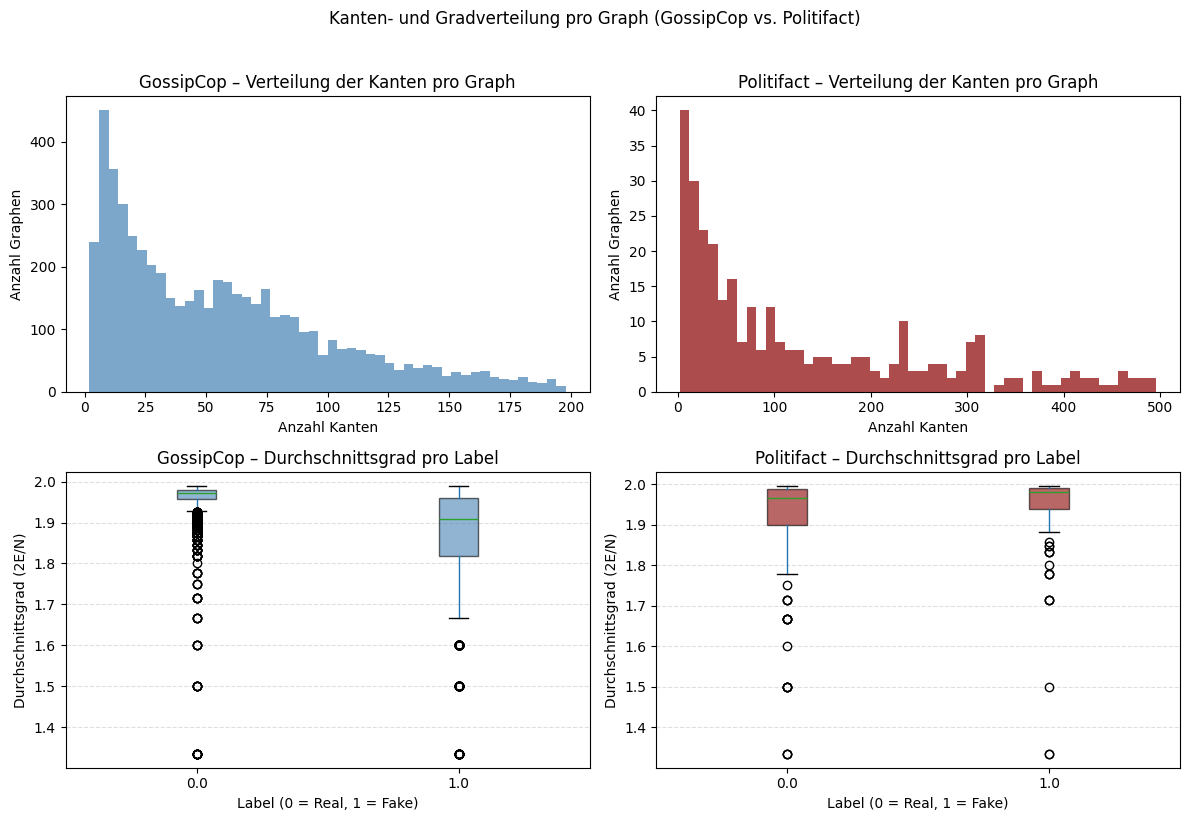

In [19]:
# Funktion - berechnet Knoten, Kanten, Dichte
def compute_graph_stats(edges, node_graph_id, graph_labels, name):
    """
    Berechne Knotenzahl, Kantenzahl und Dichte pro Graph.
    Liefert vollständigen DataFrame für strukturielle Analysen (z. B. Dichte, Grad, Boxplots).
    """
    graph_stats = []

    # alle Graphen
    for g_id in tqdm(range(len(graph_labels))):
        nodes = np.where(node_graph_id == g_id)[0]
        num_nodes = len(nodes)

        # Kanten extrahieren (nur die die zwischen diesen Nodes verlaufen)
        edges_sub = edges[np.isin(edges[:, 0], nodes) & np.isin(edges[:, 1], nodes)]
        num_edges = len(edges_sub)

        # einfache Strukturmetrik
        density = 0 if num_nodes <= 1 else (2 * num_edges) / (num_nodes * (num_nodes - 1))

        graph_stats.append({
            "graph_id": g_id,
            "num_nodes": num_nodes,
            "num_edges": num_edges,
            "density": density,
            "label": graph_labels[g_id],
            "source": name
        })

    df = pd.DataFrame(graph_stats)

    
    print(f"\n{name} – Grundstatistik (pro Label)")
    display(df.groupby("label")[["num_nodes", "num_edges", "density"]].describe())

    return df


# Statistiken für beide Datensätze
graph_stats_gos = compute_graph_stats(edges_gos, node_graph_id_gos, graph_labels_gos, "GossipCop")
graph_stats_pol = compute_graph_stats(edges_pol, node_graph_id_pol, graph_labels_pol, "Politifact")

# Durchschnittsgrad pro Graph
graph_stats_gos["avg_degree"] = 2 * graph_stats_gos["num_edges"] / graph_stats_gos["num_nodes"]
graph_stats_pol["avg_degree"] = 2 * graph_stats_pol["num_edges"] / graph_stats_pol["num_nodes"]

# Übersicht der Kennzahlen
print("GossipCop – Durchschnittsgrad & Kanten pro Label")
display(graph_stats_gos.groupby("label")[["num_edges", "avg_degree"]].describe())

print("Politifact – Durchschnittsgrad & Kanten pro Label")
display(graph_stats_pol.groupby("label")[["num_edges", "avg_degree"]].describe())


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogramm Kanten pro Graph
axes[0, 0].hist(graph_stats_gos["num_edges"], bins=50, color="steelblue", alpha=0.7)
axes[0, 0].set_title("GossipCop – Verteilung der Kanten pro Graph")
axes[0, 0].set_xlabel("Anzahl Kanten")
axes[0, 0].set_ylabel("Anzahl Graphen")

axes[0, 1].hist(graph_stats_pol["num_edges"], bins=50, color="darkred", alpha=0.7)
axes[0, 1].set_title("Politifact – Verteilung der Kanten pro Graph")
axes[0, 1].set_xlabel("Anzahl Kanten")
axes[0, 1].set_ylabel("Anzahl Graphen")

# Boxplots durchschnittlichen Grades nach Label
graph_stats_gos.boxplot(column="avg_degree", by="label", grid=False,
                        patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
                        ax=axes[1, 0])
axes[1, 0].set_title("GossipCop – Durchschnittsgrad pro Label")
axes[1, 0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 0].set_ylabel("Durchschnittsgrad (2E/N)")
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4)

graph_stats_pol.boxplot(column="avg_degree", by="label", grid=False,
                        patch_artist=True, boxprops=dict(facecolor="darkred", alpha=0.6),
                        ax=axes[1, 1])
axes[1, 1].set_title("Politifact – Durchschnittsgrad pro Label")
axes[1, 1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 1].set_ylabel("Durchschnittsgrad (2E/N)")
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Kanten- und Gradverteilung pro Graph (GossipCop vs. Politifact)", y=1.02)
plt.tight_layout()
plt.show()


Die Analyse der Graphstrukturen zeigt deutliche Unterschiede in der Art und Weise, wie sich Fake- und Real-News in sozialen Netzwerken verbreiten. Dabei wurden für jeden News-Graphen unter anderem die Anzahl der Knoten (Nutzer), die Anzahl der Kanten (Interaktionen), die Netzwerkdichte sowie der durchschnittliche Knotengrad berechnet.  

**GossipCop (Unterhaltungs- und Promi-Nachrichten)**  
Für den GossipCop-Datensatz zeigt sich, dass Real-News im Durchschnitt deutlich größere und stärker vernetzte Diskussionsnetzwerke aufweisen (Ø 76 Knoten, Ø 75 Kanten), während Fake-News sich typischerweise in kleineren Netzwerken verbreiten (Ø 39 Knoten, Ø 38 Kanten). Auffällig ist jedoch, dass Fake-News in diesem Kontext eine höhere Dichte aufweisen (Ø 0.12 gegenüber Ø 0.04 bei Real-News).

Dies bedeutet, dass Nutzer, die Fake-News teilen oder kommentieren, untereinander stärker verbunden sind, obwohl die Gesamtreichweite geringer ist. Dies kann auf koordinierte oder homogene Nutzergruppen hindeuten, die Inhalte gezielt innerhalb einer geschlossenen Community verbreiten. Die Struktur entspricht einem "Cluster-Verstärkungs"-Muster, wie es häufig auch bei automatisierten oder kampagnenartig gesteuerten Accounts beobachtet wird.

**Politifact (Politische Nachrichten)**  
Im Politifact-Datensatz zeigt sich ein umgekehrtes Bild: Fake-News erreichen hier im Schnitt mehr Nutzer (Ø 147 Knoten gegenüber Ø 115 bei Real-News) und erzeugen auch mehr Interaktionen (Ø 146 vs. Ø 119 Kanten). Gleichzeitig ist die Netzwerkdichte bei Fake-News jedoch geringer (Ø 0.005 gegenüber Ø 0.009 bei Real-News).

Dies deutet darauf hin, dass Fake-News in politischen Kontexten stärker viral und breit gestreut werden, ohne dass die Akteure besonders eng miteinander vernetzt sind. Die Verbreitung erfolgt damit eher über weite, lose Interaktionsnetzwerke, beispielsweise durch Empörung, politische Polarisierung oder algorithmisch verstärktes Teilen. Im Gegensatz zu GossipCop entsteht hier weniger ein geschlossenes Cluster, sondern ein "Streuungs-" bzw. Viralitätsmuster.


Die Ergebnisse legen nahe, dass sich Fake-News nicht einheitlich, sondern in plattformspezifischen und thematischen Mustern verbreiten:  

| Datensatz      | Charakteristik von Fake-News-Netzwerken              | Interpretation                                                |
| -------------- | ---------------------------------------------------- | ------------------------------------------------------------- |
| **GossipCop**  | Kleine, aber dichte Netzwerke                        | Verbreitung in geschlossenen, evtl. koordinierten Communities |
| **Politifact** | Große, weit verzweigte Netzwerke mit geringer Dichte | Viralität durch breite, lose verknüpfte Nutzergruppen         |


Während Fake-News im Unterhaltungsbereich primär in kompakten, möglicherweise orchestrierten Strukturen auftreten, verbreiten sie sich im politischen Bereich über größere, weniger verdichtete Netzwerke. Daraus ergibt sich, dass Netzwerkmetriken wie Dichte und Reichweite kontextabhängig interpretiert werden müssen und sich unterschiedliche Strategien zur Erkennung von Fake-News anbieten (Clusteranalyse vs. Viralitätsanalyse).

Die Histogramme zur Verteilung der Kanten pro Graph unterstreichen diese Erkenntnise zusätzlich. In beiden Datensätzen zeigt sich eine deutlich rechtsschiefe Verteilung: Die große Mehrheit der Nachrichten verbreitet sich über sehr kleine Netzwerke, während nur wenige Fälle eine hohe Reichweite erzielen. Auffällig ist dabei, dass die Graphen im Politifact-Datensatz insgesamt größer und breiter verteilt sind als bei GossipCop. Dies bestätigt, dass politische Inhalte tendenziell stärkere Nutzerreaktionen und diffusere Verbreitungsmuster auslösen als Unterhaltungs- oder Promi-bezogene Nachrichten.

Die Boxplots des durchschnittlichen Knotengrades verdeutlichen zudem, dass die grundsätzliche Netzwerkdichte in beiden Datensätzen ähnlich niedrig ist, unabhängig davon, ob es sich um Fake- oder Real-News handelt. Die Unterschiede liegen daher weniger in der lokalen Verbindung einzelner Nutzer, sondern vor allem in Größe und Form der Diffusionsnetzwerke. Spannend ist jedoch die Variation innerhalb der Gruppen:  

Bei GossipCop zeigen die Fake-News-Graphen eine geringere Streuung und wirken strukturell homogener, was das zuvor beschriebene Cluster-Verstärkungs-Muster bestätigt.  
Bei Politifact hingegen weisen insbesondere die Fake-News-Graphen eine höhere Varianz im Verbindungsverhalten auf, was auf heterogenere, dynamischere und stärker viral getriebene Diffusionsstrukturen hindeutet.  

Insgesamt bestätigt die visuelle Analyse der Verteilungen somit die zuvor beschriebenen Muster: Fake-News entfalten je nach Kontext völlig unterschiedliche Netzwerkcharakteristika - kompakt und eng vernetzt im Unterhaltungsbereich, weitreichend und diffus im politischen Diskurs.

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,2732.0,76.163616,40.627898,3.0,48.0,70.0,99.0,199.0
1.0,2732.0,38.866398,41.784859,3.0,11.0,22.0,50.0,198.0


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,157.0,114.917197,129.465814,3.0,20.0,58.0,170.0,497.0
1.0,157.0,146.573248,130.135541,3.0,33.0,104.0,233.0,487.0


GossipCop                                                     Politifact                                                        
          count       mean        std  min   25%   50%   75%    max      count        mean         std  min   25%    50%    75%    max
label                                                                                                                                 
0.0      2732.0  76.163616  40.627898  3.0  48.0  70.0  99.0  199.0      157.0  114.917197  129.465814  3.0  20.0   58.0  170.0  497.0
1.0      2732.0  38.866398  41.784859  3.0  11.0  22.0  50.0  198.0      157.0  146.573248  130.135541  3.0  33.0  104.0  233.0  487.0

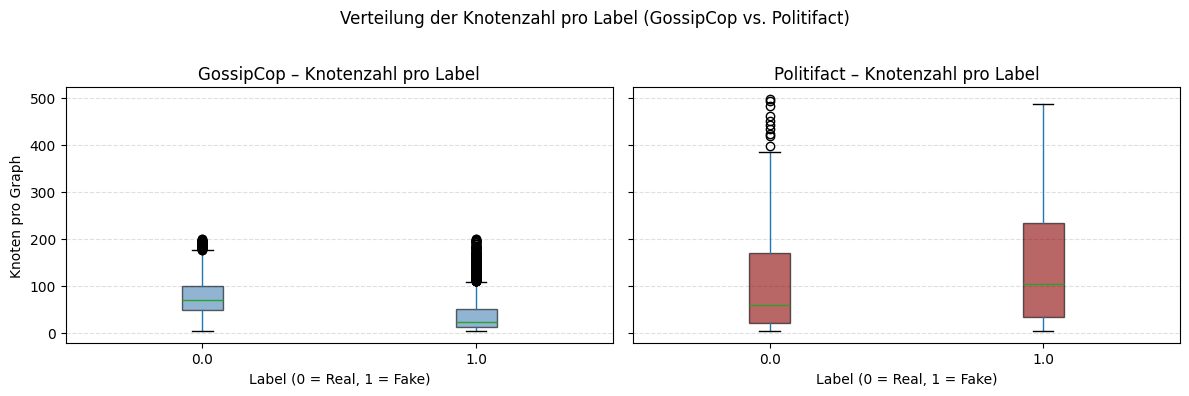

In [20]:
# Funktion - Berechnung pro Datensatz
def graph_size_stats(node_graph_id, graph_labels, name):
    """Erzeuge DataFrame mit Knotenzahl pro Graph und Label."""
    graph_sizes = pd.Series(node_graph_id).value_counts().sort_index()
    df = pd.DataFrame({
        "graph_id": range(len(graph_labels)),
        "label": graph_labels,
        "num_nodes": graph_sizes.values
    })
    stats = df.groupby("label")["num_nodes"].describe()
    display(stats)
    return df, stats

graph_df_gos, stats_gos = graph_size_stats(node_graph_id_gos, graph_labels_gos, "GossipCop")
graph_df_pol, stats_pol = graph_size_stats(node_graph_id_pol, graph_labels_pol, "Politifact")

# Zusammenfassung
summary = pd.concat(
    {"GossipCop": stats_gos, "Politifact": stats_pol},
    axis=1
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# GossipCop
graph_df_gos.boxplot(
    column="num_nodes", by="label", grid=False,
    patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
    ax=axes[0]
)
axes[0].set_title("GossipCop – Knotenzahl pro Label")
axes[0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[0].set_ylabel("Knoten pro Graph")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact
graph_df_pol.boxplot(
    column="num_nodes", by="label", grid=False,
    patch_artist=True, boxprops=dict(facecolor="darkred", alpha=0.6),
    ax=axes[1]
)
axes[1].set_title("Politifact – Knotenzahl pro Label")
axes[1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Verteilung der Knotenzahl pro Label (GossipCop vs. Politifact)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Die Boxplots zeigen, dass sich die Diffusionsgröße (Knotenzahl pro Graph) zwischen Fake- und Real-News unterscheidet:  
Bei GossipCop verbreiten sich Fake-News tendenziell über kleinere Netzwerke, während Real-News eine etwas größere Reichweite erzielen.
Bei Politifact ist der Unterschied weniger ausgeprägt, dort erreichen Fake-News sogar ähnlich große oder größere Netzwerke, was auf eine stärkere politische Viralität hindeutet.  

Die Analyse der Knotenzahl bringt keine widersprüchlichen Erkenntnisse hervor, sondern bestätigt die zuvor beobachteten Diffusionsmuster.

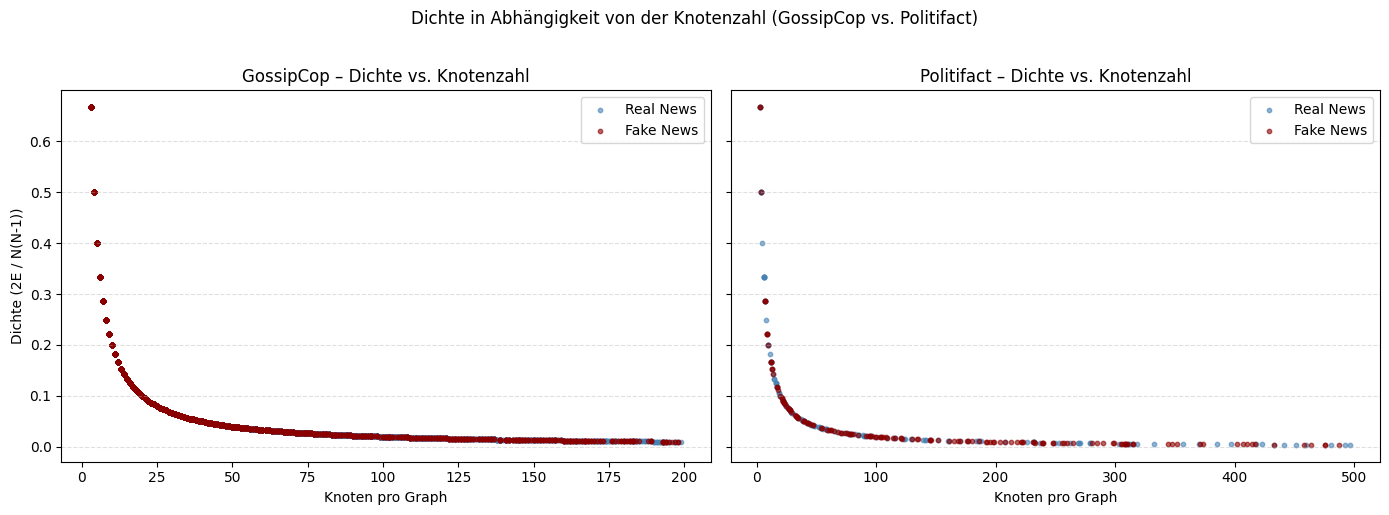

In [21]:
# Scatterplot: Dichte vs. Knotenzahl (für beide Datensätze)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# GossipCop
axes[0].scatter(
    graph_stats_gos.loc[graph_stats_gos["label"] == 0, "num_nodes"],
    graph_stats_gos.loc[graph_stats_gos["label"] == 0, "density"],
    s=10, alpha=0.6, label="Real News", color="steelblue"
)

axes[0].scatter(
    graph_stats_gos.loc[graph_stats_gos["label"] == 1, "num_nodes"],
    graph_stats_gos.loc[graph_stats_gos["label"] == 1, "density"],
    s=10, alpha=0.6, label="Fake News", color="darkred"
)

axes[0].set_title("GossipCop – Dichte vs. Knotenzahl")
axes[0].set_xlabel("Knoten pro Graph")
axes[0].set_ylabel("Dichte (2E / N(N-1))")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact
axes[1].scatter(
    graph_stats_pol.loc[graph_stats_pol["label"] == 0, "num_nodes"],
    graph_stats_pol.loc[graph_stats_pol["label"] == 0, "density"],
    s=10, alpha=0.6, label="Real News", color="steelblue"
)

axes[1].scatter(
    graph_stats_pol.loc[graph_stats_pol["label"] == 1, "num_nodes"],
    graph_stats_pol.loc[graph_stats_pol["label"] == 1, "density"],
    s=10, alpha=0.6, label="Fake News", color="darkred"
)

axes[1].set_title("Politifact – Dichte vs. Knotenzahl")
axes[1].set_xlabel("Knoten pro Graph")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Dichte in Abhängigkeit von der Knotenzahl (GossipCop vs. Politifact)", y=1.02)
plt.tight_layout()
plt.show()

Die Scatterplots zeigen, dass mit wachsender Knotenzahl die Netzwerkdichte in beiden Datensätzen deutlich abnimmt. In GossipCop treten Fake-News vor allem in kleineren, dafür dichter vernetzten Gruppen auf, was auf geschlossene und möglicherweise koordinierte Communities hinweist. In Politifact hingegen verbreiten sich Fake-News in größeren, aber weniger dicht verbundenen Netzwerken, was auf eine breite, viral getriebene Streuung schließen lässt. Damit bestätigt die Analyse die zuvor identifizierten Muster der Cluster-Verstärkung (GossipCop) und Viralitäts-Streuung (Politifact).

Die Scatterplots zeigen den typischen negativen Zusammenhang zwischen Knotenzahl und Dichte:  
kleinere Graphen sind deutlich dichter vernetzt, während größere Netzwerke zunehmend ausdünnen.
Bei GossipCop haben Fake-News im Mittel eine höhere Dichte, also kompaktere, stärker verbundene Diffusionsstrukturen.
Bei Politifact zeigt sich dagegen der umgekehrte Trend – Fake-News-Graphen sind größer, aber weniger dicht, was auf breitere, aber weniger stark verknüpfte Verbreitungsmuster hindeutet.

100%|██████████| 314/314 [00:00<00:00, 1851.24it/s]


Durchschnittswerte GossipCop


max_depth                                              root_centralization                                                  
          count      mean       std  min  25%  50%  75%  max               count      mean       std       min  25%  50%  75%  max
label                                                                                                                             
0.0      2732.0  2.480600  0.893438  2.0  2.0  2.0  3.0  8.0              2732.0  0.980135  0.099750  0.035714  1.0  1.0  1.0  1.0
1.0      2732.0  2.543192  1.001994  2.0  2.0  2.0  3.0  9.0              2732.0  0.960704  0.142763  0.014286  1.0  1.0  1.0  1.0


Durchschnittswerte Politifact


max_depth                                               root_centralization                                                  
          count      mean       std  min  25%  50%  75%   max               count      mean       std       min  25%  50%  75%  max
label                                                                                                                              
0.0       157.0  3.624204  1.634618  2.0  2.0  3.0  5.0  12.0               157.0  0.925691  0.212376  0.060606  1.0  1.0  1.0  1.0
1.0       157.0  3.885350  1.523189  2.0  3.0  4.0  5.0   9.0               157.0  0.933200  0.199801  0.111111  1.0  1.0  1.0  1.0

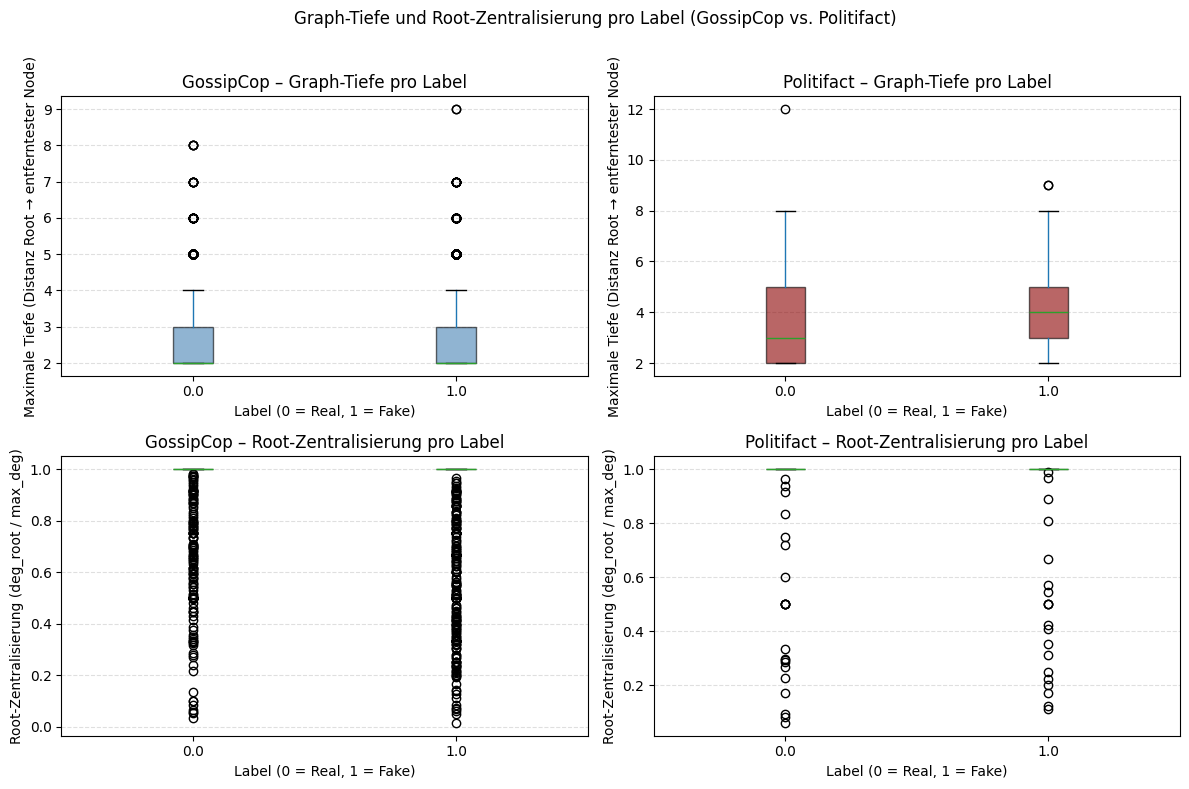

In [23]:
# Berechne Tiefe und Zentralisierung pro Graph
def compute_depth_and_centralization(edges, node_graph_id, graph_labels, name):
    """
    Berechnet:
      - max_depth: maximale Distanz vom Root-Node zum entferntesten Node
      - root_centralization: Anteil der Kanten, die direkt vom Root ausgehen
    Gibt DataFrame zurück.
    """
    stats = []

    for g_id in tqdm(range(len(graph_labels))):
        nodes = np.where(node_graph_id == g_id)[0]
        edges_sub = edges[
            np.isin(edges[:, 0], nodes) & np.isin(edges[:, 1], nodes)
        ]

        if len(nodes) == 0 or len(edges_sub) == 0:
            stats.append({"graph_id": g_id, "label": graph_labels[g_id],
                          "max_depth": 0, "root_centralization": 0, "source": name})
            continue

        # Graph konstruiere
        G = nx.Graph()
        G.add_edges_from(edges_sub)

        # Root finden
        # Root-Node ist typischerweise der Knoten mit minimalem Index im Graph
        root = nodes[0]  # Annahme -der erste Knoten ist die Quelle der Nachricht

        # Graph-Tiefe
        try:
            lengths = nx.single_source_shortest_path_length(G, root)
            max_depth = max(lengths.values())
        except Exception:
            max_depth = 0

        # Root-Zentralisierung
        root_deg = G.degree(root)
        max_deg = max(dict(G.degree()).values()) if len(G) > 0 else 1
        root_centralization = root_deg / max_deg if max_deg > 0 else 0

        stats.append({
            "graph_id": g_id,
            "label": graph_labels[g_id],
            "max_depth": max_depth,
            "root_centralization": root_centralization,
            "source": name
        })

    return pd.DataFrame(stats)


depth_central_gos = compute_depth_and_centralization(edges_gos, node_graph_id_gos, graph_labels_gos, "GossipCop")
depth_central_pol = compute_depth_and_centralization(edges_pol, node_graph_id_pol, graph_labels_pol, "Politifact")

# Statistik
print("\nDurchschnittswerte GossipCop")
display(depth_central_gos.groupby("label")[["max_depth", "root_centralization"]].describe())

print("\nDurchschnittswerte Politifact")
display(depth_central_pol.groupby("label")[["max_depth", "root_centralization"]].describe())


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

# GossipCop – Tiefe
depth_central_gos.boxplot(column="max_depth", by="label", grid=False,
                          patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
                          ax=axes[0, 0])
axes[0, 0].set_title("GossipCop – Graph-Tiefe pro Label")
axes[0, 0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[0, 0].set_ylabel("Maximale Tiefe (Distanz Root → entferntester Node)")
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact – Tiefe
depth_central_pol.boxplot(column="max_depth", by="label", grid=False,
                          patch_artist=True, boxprops=dict(facecolor="darkred", alpha=0.6),
                          ax=axes[0, 1])
axes[0, 1].set_title("Politifact – Graph-Tiefe pro Label")
axes[0, 1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[0, 1].set_ylabel("Maximale Tiefe (Distanz Root → entferntester Node)")
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.4)

# GossipCop – Zentralisierung
depth_central_gos.boxplot(column="root_centralization", by="label", grid=False,
                          patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6),
                          ax=axes[1, 0])
axes[1, 0].set_title("GossipCop – Root-Zentralisierung pro Label")
axes[1, 0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 0].set_ylabel("Root-Zentralisierung (deg_root / max_deg)")
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact – Zentralisierung
depth_central_pol.boxplot(column="root_centralization", by="label", grid=False,
                          patch_artist=True, boxprops=dict(facecolor="darkred", alpha=0.6),
                          ax=axes[1, 1])
axes[1, 1].set_title("Politifact – Root-Zentralisierung pro Label")
axes[1, 1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 1].set_ylabel("Root-Zentralisierung (deg_root / max_deg)")
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Graph-Tiefe und Root-Zentralisierung pro Label (GossipCop vs. Politifact)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


max_depth: Wie tief sich eine Nachricht im Netzwerk verzweigt (wie "lange" sie weiterverbreitet wird)  
root_centralization: Wie stark die Verteilung vom Ursprungspost bzw. einem zentralen Knoten abhängt  

Die Visualisierungen zeigen, dass die meisten Diffusionsgraphen sehr flach und stark zentralisiert sind - also fast ausschließlich direkte Verbindungen vom Root-Node zu den Nutzern bestehen.  
Politifact-News verbreiten sich tendenziell tiefer und über mehr Zwischenstufen als GossipCop-News, was auf komplexere politische Diskussionsstrukturen hinweist.  
Die nahezu vollständige Root-Zentralisierung (~1.0) bestätigt, dass beide Datensätze überwiegend sternförmige Diffusionsmuster aufweisen, bei denen der Ursprung die Verbreitung dominiert.  

### Inhaltsbezogene Merkmale (Text/Embeddings auf Graph-Ebene)


Übersicht: Mittelwert & Standardabweichung pro Feature und Datensatz


,Datensatz,Feature,Mean,Std,Shape
0,GossipCop,BERT,-0.029368,0.868200,"(314262, 768)"
1,GossipCop,Content,0.491564,0.115785,"(314262, 310)"
2,GossipCop,Profile,0.115690,0.240191,"(314262, 10)"
3,GossipCop,Spacy,-0.000353,0.117566,"(314262, 300)"
4,Politifact,BERT,-0.028567,0.854548,"(41054, 768)"
5,Politifact,Content,0.505308,0.148701,"(41054, 310)"
6,Politifact,Profile,0.135509,0.250787,"(41054, 10)"
7,Politifact,Spacy,0.002169,0.119035,"(41054, 300)"


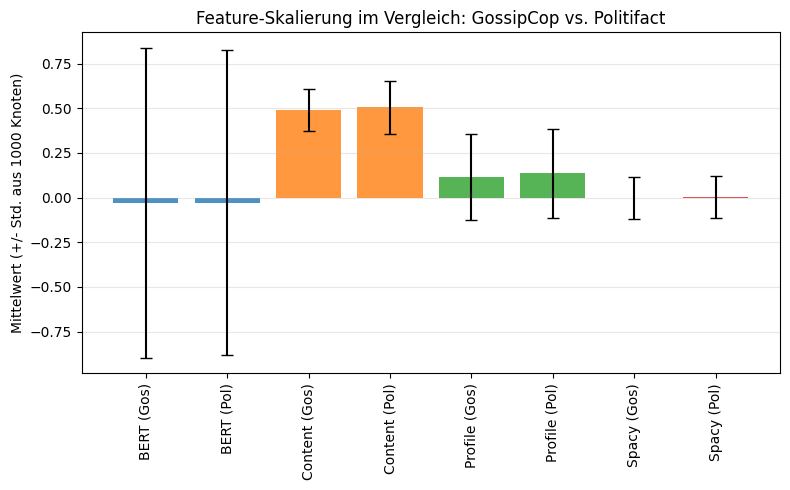

In [24]:
# Hilfsfunktion für Feature-Statistiken
def feature_summary(name, matrices):
    results = []
    for ds_name, mats in matrices.items():
        for feat_name, mat in mats.items():
            dense = mat[:1000].toarray()  # kleine Stichprobe (~1000 Knoten)
            results.append({
                "Datensatz": ds_name,
                "Feature": feat_name,
                "Mean": dense.mean(),
                "Std": dense.std(),
                "Shape": mat.shape
            })
    return pd.DataFrame(results)

feature_matrices = {
    "GossipCop": {
        "BERT": bert_features_gos,
        "Content": content_features_gos,
        "Profile": profile_features_gos,
        "Spacy": spacy_features_gos
    },
    "Politifact": {
        "BERT": bert_features_pol,
        "Content": content_features_pol,
        "Profile": profile_features_pol,
        "Spacy": spacy_features_pol
    }
}

# Berechnung
feature_stats = feature_summary("Features", feature_matrices)

print("\nÜbersicht: Mittelwert & Standardabweichung pro Feature und Datensatz")
display(feature_stats.head(30))

plt.figure(figsize=(8,5))

for i, feat in enumerate(["BERT", "Content", "Profile", "Spacy"]):
    subset = feature_stats[feature_stats["Feature"] == feat]
    plt.bar([feat + " (Gos)", feat + " (Pol)"],
            subset["Mean"],
            yerr=subset["Std"],
            capsize=4,
            alpha=0.8)
    


plt.ylabel("Mittelwert (+/- Std. aus 1000 Knoten)")
plt.title("Feature-Skalierung im Vergleich: GossipCop vs. Politifact")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


Die Abbildung zeigt die Mittelwerte und Standardabweichungen der inhaltlichen Features für beide Datensätze.
Die BERT- und Spacy-Embeddings liegen zentriert um den Nullpunkt mit hoher Varianz - was auf eine hohe Informationsdichte und semantische Vielfalt hinweist.  
Die Content-Features besitzen dagegen positive Mittelwerte und geringere Streuungen, was auf homogenere und stilistisch konsistentere Inhalte schließen lässt.
Insgesamt sind die Skalenverteilungen von GossipCop und Politifact ähnlich, wodurch eine einheitliche Normalisierung der Features möglich ist.

Besonders BERT zeigt mit einer Varianz von +/- 0.85 und einem zentrierten Mittelwert (~0) das ideale Verhalten für eine PCA-Analyse.   
es bietet viele Dimensionen mit starker semantischer Variation und keine systematische Verschiebung (offset) im Wertebereich.  
Content- und Profile-Features eignen sich eher als ergänzende Eingaben für klassische ML-Modelle, da ihre Varianz vermutlic zu gering ist, um komplexe semantische Strukturen abzubilden.
Die Spacy-Embeddings zeigen eine sehr geringe Streuung und sind damit stabil, aber besitzen wenig trennschärfe.

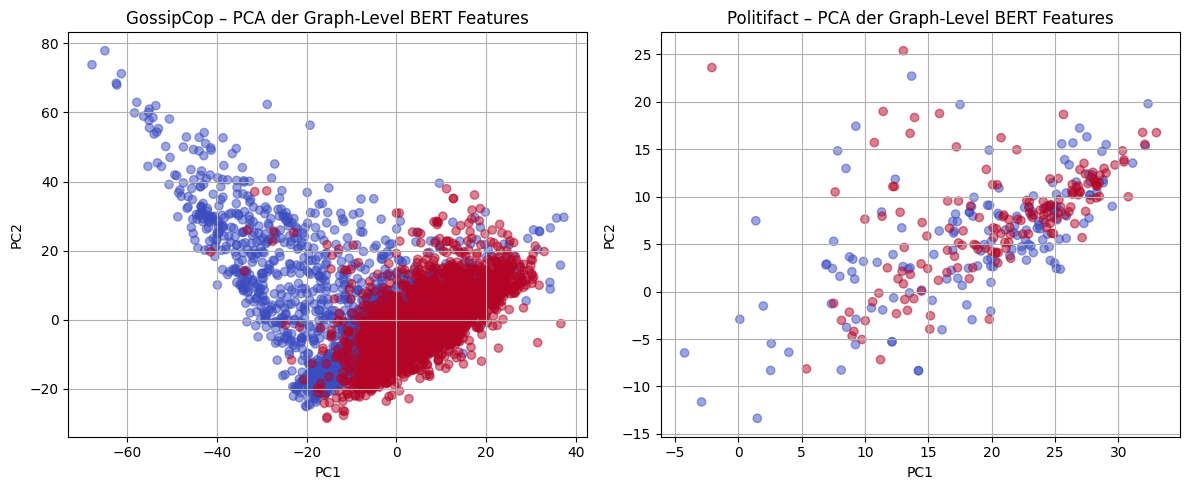

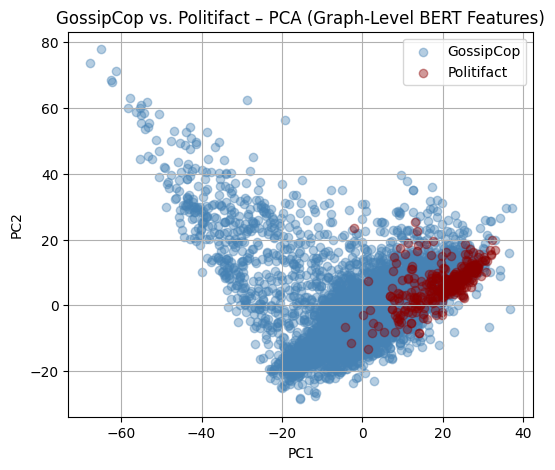

In [ ]:
def compute_graph_level_features(bert_features, node_graph_id, graph_labels):
    """Berechnet den Durchschnitt der BERT-Features pro Graph."""
    mean_features = []
    for g_id in range(len(graph_labels)):
        nodes = np.where(node_graph_id == g_id)[0]
        mean_features.append(bert_features[nodes].mean(axis=0).A1)
    X = np.vstack(mean_features)
    y = graph_labels
    return X, y

# BERT-Mittelwerte für beide Datensätze
X_gos, y_gos = compute_graph_level_features(bert_features_gos, node_graph_id_gos, graph_labels_gos)
X_pol, y_pol = compute_graph_level_features(bert_features_pol, node_graph_id_pol, graph_labels_pol)

# PCA auf gemeinsamen Maßstab bringen
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(np.vstack([X_gos, X_pol]))

# Splitpunkte merken (für Vis)
split = len(X_gos)
X_gos_scaled, X_pol_scaled = X_all_scaled[:split], X_all_scaled[split:]

# PCA (gemeinsam)
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all_scaled)
X_gos_pca, X_pol_pca = X_all_pca[:split], X_all_pca[split:]

plt.figure(figsize=(12,5))

# 0 = Real (blau), 1 = Fake (rot)
real_patch = mpatches.Patch(color=plt.cm.coolwarm(0.05), label="Real")
fake_patch = mpatches.Patch(color=plt.cm.coolwarm(0.95), label="Fake")
legend_handles = [real_patch, fake_patch]

# GossipCop
plt.subplot(1,2,1)
plt.scatter(X_gos_pca[:,0], X_gos_pca[:,1], c=y_gos, cmap='coolwarm', alpha=0.5)
plt.title("GossipCop – PCA der Graph-Level BERT Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend(handles=legend_handles, loc="best")

# Politifact
plt.subplot(1,2,2)
plt.scatter(X_pol_pca[:,0], X_pol_pca[:,1], c=y_pol, cmap='coolwarm', alpha=0.5)
plt.title("Politifact – PCA der Graph-Level BERT Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend(handles=legend_handles, loc="best")

plt.tight_layout()
plt.show()

# Überlagerte PCA zur Domänenunterscheidung
plt.figure(figsize=(6,5))
plt.scatter(X_gos_pca[:,0], X_gos_pca[:,1], c='steelblue', label='GossipCop', alpha=0.4)
plt.scatter(X_pol_pca[:,0], X_pol_pca[:,1], c='darkred', label='Politifact', alpha=0.4)
plt.title("GossipCop vs. Politifact – PCA (Graph-Level BERT Features)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


Die PCA der Graph-Level-BERT-Embeddings zeigt deutliche semantische Unterschiede zwischen den Datensätzen.  
Bei GossipCop ist eine größere Streuung der Punkte sichtbar, was auf inhaltlich vielfältigere und thematisch breitere Nachrichten hinweist.  
Die Politifact-Graphen liegen enger beieinander und bilden kompaktere Cluster, was auf inhaltlich homogenere politische Diskussionen schließen lässt.  
Zwischen Fake- und Real-News ist eine teilweise Trennung erkennbar, was zeigt, dass sich die Textinhalte semantisch unterscheiden, jedoch nicht vollständig separierbar sind.  

### Nutzerbezogene Merkmale (aggregiert pro Graph)

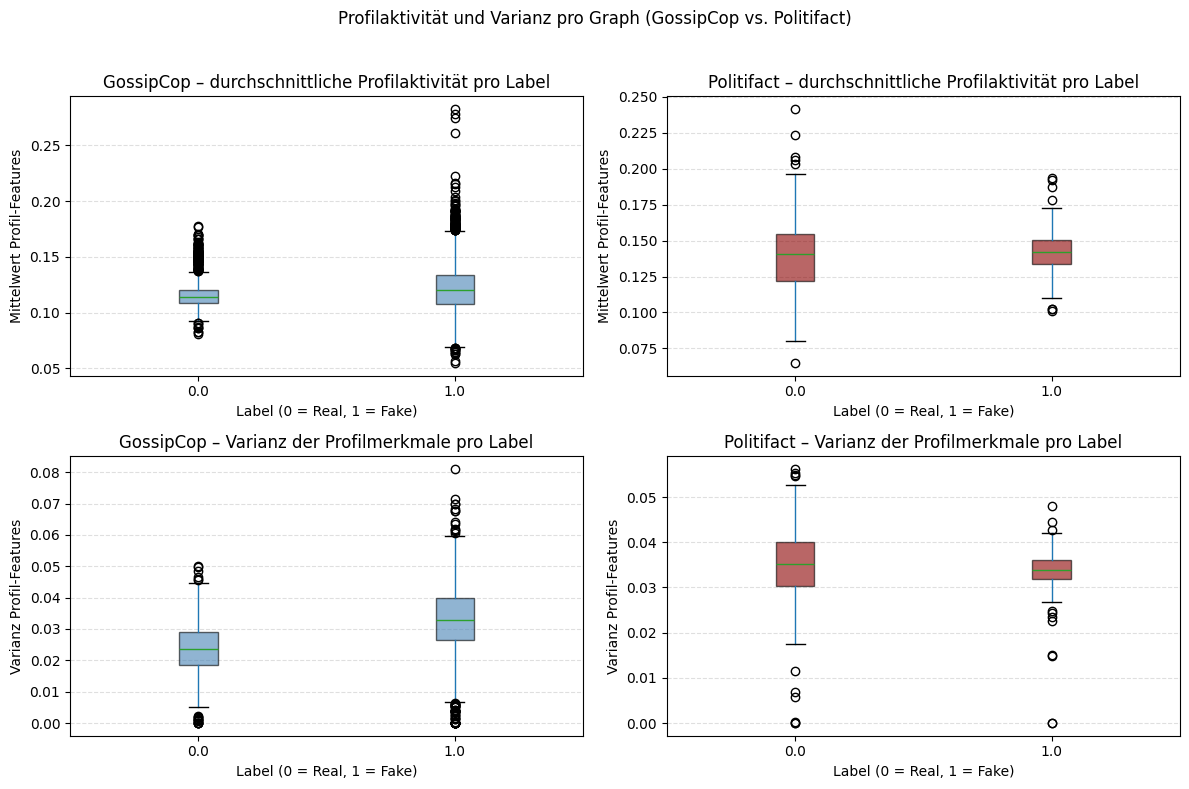

In [26]:
# Funktio - Aggregation der Profilmerkmale pro Graph
def aggregate_profile_features(profile_features, node_graph_id, graph_labels, name):

    # Falls sparse Matrix - in dense umwandeln
    profile_dense = profile_features.toarray()
    df_profile = pd.DataFrame(profile_dense)
    df_profile["graph_id"] = node_graph_id

    # Durchschnittliche Profilaktivität pro Graph (Mittelwert über alle 10 Spalten)
    mean_activity = (
        df_profile.groupby("graph_id")
        .mean()
        .mean(axis=1)
        .rename("mean_profile_activity")
    )

    # Varianz der Profilmerkmale innerhalb jedes Graphen
    var_activity = (
        df_profile.groupby("graph_id")
        .var()
        .mean(axis=1)
        .rename("var_profile_activity")
    )

    df_graph = pd.concat([mean_activity, var_activity], axis=1).reset_index()
    df_graph["label"] = graph_labels[df_graph["graph_id"]]
    df_graph["source"] = name

    return df_graph


# Aggregation
profile_gos_agg = aggregate_profile_features(
    profile_features_gos, node_graph_id_gos, graph_labels_gos, "GossipCop"
)
profile_pol_agg = aggregate_profile_features(
    profile_features_pol, node_graph_id_pol, graph_labels_pol, "Politifact"
)


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

# GossipCop - Durchschnittliche Aktivität
profile_gos_agg.boxplot(
    column="mean_profile_activity",
    by="label",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    ax=axes[0, 0],
)
axes[0, 0].set_title("GossipCop – durchschnittliche Profilaktivität pro Label")
axes[0, 0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[0, 0].set_ylabel("Mittelwert Profil-Features")
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact - Durchschnittliche Aktivität
profile_pol_agg.boxplot(
    column="mean_profile_activity",
    by="label",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="darkred", alpha=0.6),
    ax=axes[0, 1],
)
axes[0, 1].set_title("Politifact – durchschnittliche Profilaktivität pro Label")
axes[0, 1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[0, 1].set_ylabel("Mittelwert Profil-Features")
axes[0, 1].grid(axis="y", linestyle="--", alpha=0.4)

# GossipCop - Varianz
profile_gos_agg.boxplot(
    column="var_profile_activity",
    by="label",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    ax=axes[1, 0],
)
axes[1, 0].set_title("GossipCop – Varianz der Profilmerkmale pro Label")
axes[1, 0].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 0].set_ylabel("Varianz Profil-Features")
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.4)

# Politifact - Varianz
profile_pol_agg.boxplot(
    column="var_profile_activity",
    by="label",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="darkred", alpha=0.6),
    ax=axes[1, 1],
)
axes[1, 1].set_title("Politifact – Varianz der Profilmerkmale pro Label")
axes[1, 1].set_xlabel("Label (0 = Real, 1 = Fake)")
axes[1, 1].set_ylabel("Varianz Profil-Features")
axes[1, 1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Profilaktivität und Varianz pro Graph (GossipCop vs. Politifact)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Die Boxplots zeigen deutliche Unterschiede in der Profilaktivität und Heterogenität der Nutzer zwischen Fake- und Real-News.  
Bei GossipCop sind Fake-News tendenziell mit etwas aktiveren und zugleich homogeneren Nutzerprofilen verbunden, was auf koordiniertere Verbreitung hindeutet.  
Bei Politifact hingegen liegt die durchschnittliche Aktivität für beide Label höher, wobei Real-News eine größere Varianz der Profilmerkmale aufweisen.

### Zeitliche Dynamik (Diffusionsverlauf über Zeit)  

Nicht implementiert.

## Node-Ebene (ein Datenpunkt = ein Nutzer/Knoten innerhalb eines Graphen)

### Strukturelle Merkmale der Diffusion (lokale Netzwerkposition)

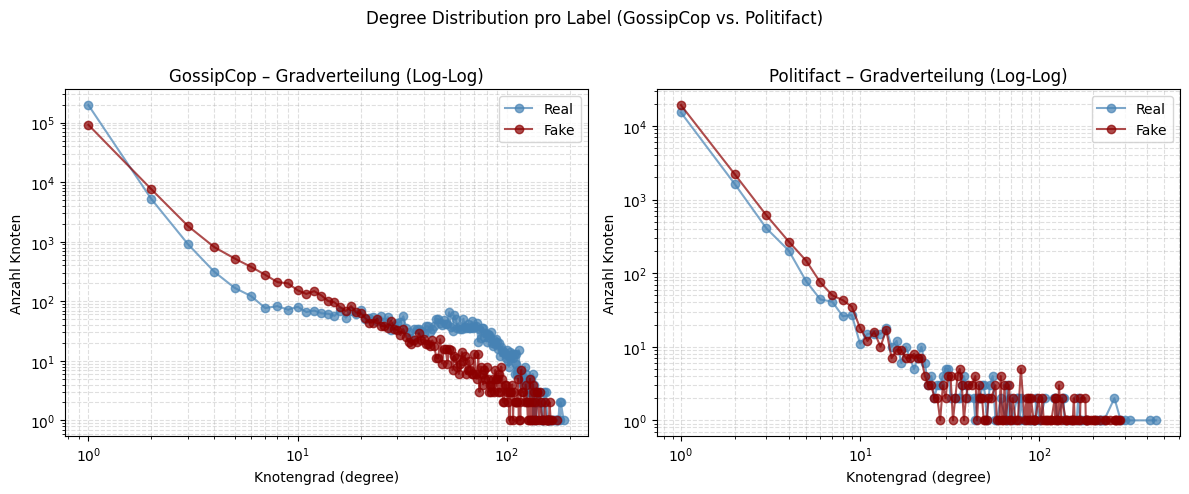

In [27]:
# Funktion- Berechne Knotengrade und Labels
def compute_node_degrees(edges, node_graph_id, graph_labels, name):
    G = nx.Graph()
    G.add_edges_from(edges)

    degrees = np.array([G.degree(n) for n in range(len(node_graph_id))])
    node_df = pd.DataFrame({
        "node_id": range(len(node_graph_id)),
        "graph_id": node_graph_id,
        "degree": degrees
    })
    node_df["label"] = graph_labels[node_df["graph_id"]]
    node_df["source"] = name
    return node_df


node_degrees_gos = compute_node_degrees(edges_gos, node_graph_id_gos, graph_labels_gos, "GossipCop")
node_degrees_pol = compute_node_degrees(edges_pol, node_graph_id_pol, graph_labels_pol, "Politifact")

# Log-Log Degree Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (node_df, title, color_real, color_fake) in zip(
    axes,
    [
        (node_degrees_gos, "GossipCop", "steelblue", "darkred"),
        (node_degrees_pol, "Politifact", "steelblue", "darkred"),
    ],
):
    for label_val, color, label_name in zip([0, 1], [color_real, color_fake], ["Real", "Fake"]):
        degs = node_df[node_df["label"] == label_val]["degree"]
        deg_counts = np.bincount(degs)
        degs_nonzero = np.nonzero(deg_counts)[0]
        counts = deg_counts[degs_nonzero]

        ax.loglog(degs_nonzero, counts, marker="o", linestyle="-", color=color, alpha=0.7, label=label_name)

    ax.set_title(f"{title} – Gradverteilung (Log-Log)")
    ax.set_xlabel("Knotengrad (degree)")
    ax.set_ylabel("Anzahl Knoten")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.suptitle("Degree Distribution pro Label (GossipCop vs. Politifact)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Die Gradverteilungen beider Datensätze zeigen eine typische heavy-tailed Struktur, was auf das Vorhandensein weniger stark vernetzter Nutzer (Hubs) und vieler schwach vernetzter Nutzer hinweist.
Bei GossipCop fällt die Kurve für Fake-News flacher ab, was auf mehr zentral vernetzte Accounts und damit auf eine stärker gesteuerte oder konzentrierte Diffusion hindeutet.
Politifact weist dagegen eine steilere Verteilung mit weniger extremen Hubs auf, was auf eine gleichmäßigere, dezentralere Beteiligung der Nutzer schließen lässt - also eine Verbreitung, die eher durch individuelles Nutzerverhalten als durch koordinierte Akteure geprägt ist.

In [28]:
G_dir = nx.DiGraph()
G_dir.add_edges_from(edges_gos)

print("Gerichteter Graph?", G_dir.is_directed())
print("Kanten (gerichtet):", G_dir.number_of_edges())
print("Kanten (wenn ungerichtet interpretiert):", nx.Graph(G_dir).number_of_edges())


Gerichteter Graph? True
Kanten (gerichtet): 308798
Kanten (wenn ungerichtet interpretiert): 308798


Obwohl die Kanten formal in einem gerichteten Format vorliegen, zeigt der Vergleich mit der ungerichteten Repräsentation, dass die Netzwerke strukturell äquivalent zu ungerichteten Graphen sind. Eine Unterscheidung in In- und Out-Degree ist daher nicht sinnvoll, und alle Analysen können korrekt auf Basis eines ungerichteten Graphen durchgeführt werden. 

Berechnet für 5000 Knoten (GossipCop)
Label-Verteilung: {0: 3312, 1: 1688}
Enthaltene Graphen: 2788 von 5464
Berechnet für 5000 Knoten (Politifact)
Label-Verteilung: {1: 2775, 0: 2225}
Enthaltene Graphen: 286 von 314


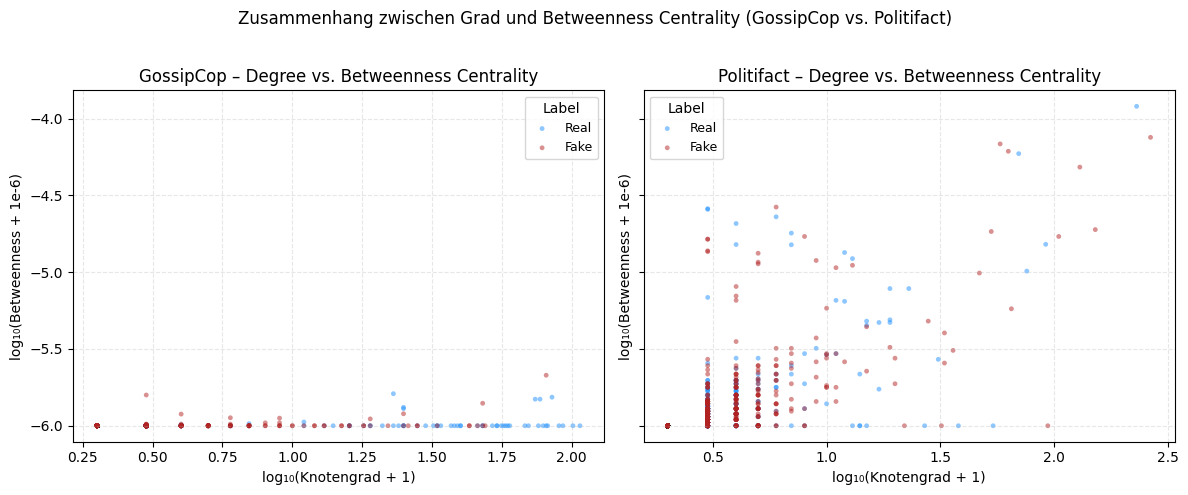

In [29]:
# Funktion - Berechnung von Degree und Betweenness pro Node
def compute_degree_betweenness(edges, node_graph_id, graph_labels, name, sample_limit=5_000, random_state=42):
    """
    Berechnet Degree und Betweenness Centrality pro Knoten.
    Falls das Netzwerk sehr groß ist, kann sample_limit zur Laufzeitreduktion genutzt werden.
    Sampling erfolgt zufällig, um Real/Fake-Mix sicherzustellen.
    """

    # Netzwerk
    G = nx.Graph()
    G.add_edges_from(edges)

    # Zufälliges Sampling über alle Knoten (statt sequentiell)
    all_nodes = list(G.nodes())
    if len(all_nodes) > sample_limit:
        np.random.seed(random_state)
        nodes_sample = np.random.choice(all_nodes, size=sample_limit, replace=False)
    else:
        nodes_sample = all_nodes

    # Metriken berechnen
    degrees = dict(G.degree(nodes_sample))
    betweenness = nx.betweenness_centrality(G, k=min(len(nodes_sample), 500), normalized=True)

    # DF erstellen
    df_nodes = pd.DataFrame({
        "node_id": list(degrees.keys()),
        "degree": list(degrees.values()),
        "betweenness": [betweenness[n] for n in degrees.keys()],
        "graph_id": node_graph_id[list(degrees.keys())]
    })

    # Labels zuordnen
    df_nodes["label"] = graph_labels[df_nodes["graph_id"]]
    df_nodes["source"] = name

    # Labels in Int konvertieren
    df_nodes["label"] = df_nodes["label"].astype(int)

    print(f"Berechnet für {len(df_nodes)} Knoten ({name})")
    print(f"Label-Verteilung: {df_nodes['label'].value_counts().to_dict()}")
    print(f"Enthaltene Graphen: {df_nodes['graph_id'].nunique()} von {len(graph_labels)}")
    return df_nodes


node_central_gos = compute_degree_betweenness(edges_gos, node_graph_id_gos, graph_labels_gos, "GossipCop")
node_central_pol = compute_degree_betweenness(edges_pol, node_graph_id_pol, graph_labels_pol, "Politifact")


# Log-Skalierung für Lesbarkeit
for df in [node_central_gos, node_central_pol]:
    df["degree_log"] = np.log10(df["degree"] + 1)
    df["betweenness_log"] = np.log10(df["betweenness"] + 1e-6)  # +epsilon gegen log(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


color_map = {0: "dodgerblue", 1: "firebrick"}

for ax, (df, title) in zip(
    axes,
    [(node_central_gos, "GossipCop"), (node_central_pol, "Politifact")]
):
    for label_val, label_name in zip([0, 1], ["Real", "Fake"]):
        subset = df[df["label"] == label_val]
        ax.scatter(
            subset["degree_log"],
            subset["betweenness_log"],
            s=12,
            alpha=0.5,
            color=color_map[label_val],
            label=label_name,
            edgecolor="none"
        )

    ax.set_title(f"{title} – Degree vs. Betweenness Centrality")
    ax.set_xlabel("log₁₀(Knotengrad + 1)")
    ax.set_ylabel("log₁₀(Betweenness + 1e-6)")
    ax.legend(title="Label", loc="best", frameon=True, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Zusammenhang zwischen Grad und Betweenness Centrality (GossipCop vs. Politifact)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Diese Visualisierung zeigt den Zusammenhang zwischen lokaler Reichweite (Degree) und Vermittlerrolle (Betweenness Centrality) einzelner Nutzer.  
Bei GossipCop konzentrieren sich die meisten Knoten auf sehr niedrige Werte beider Metriken, was auf eine stark flache, wenig hierarchische Struktur der Diffusion hinweist.
In Politifact ist die Streuung größer,insbesondere für Fake-News, was darauf schließen lässt, dass einzelne Knoten (zB. Influencer oder koordinierte Accounts) dort eine zentralere Rolle in der Informationsweiterleitung einnehmen.
Insgesamt deuten die Ergebnisse auf eine tendenziell höhere Netzwerkzentralisierung bei Fake-News hin.

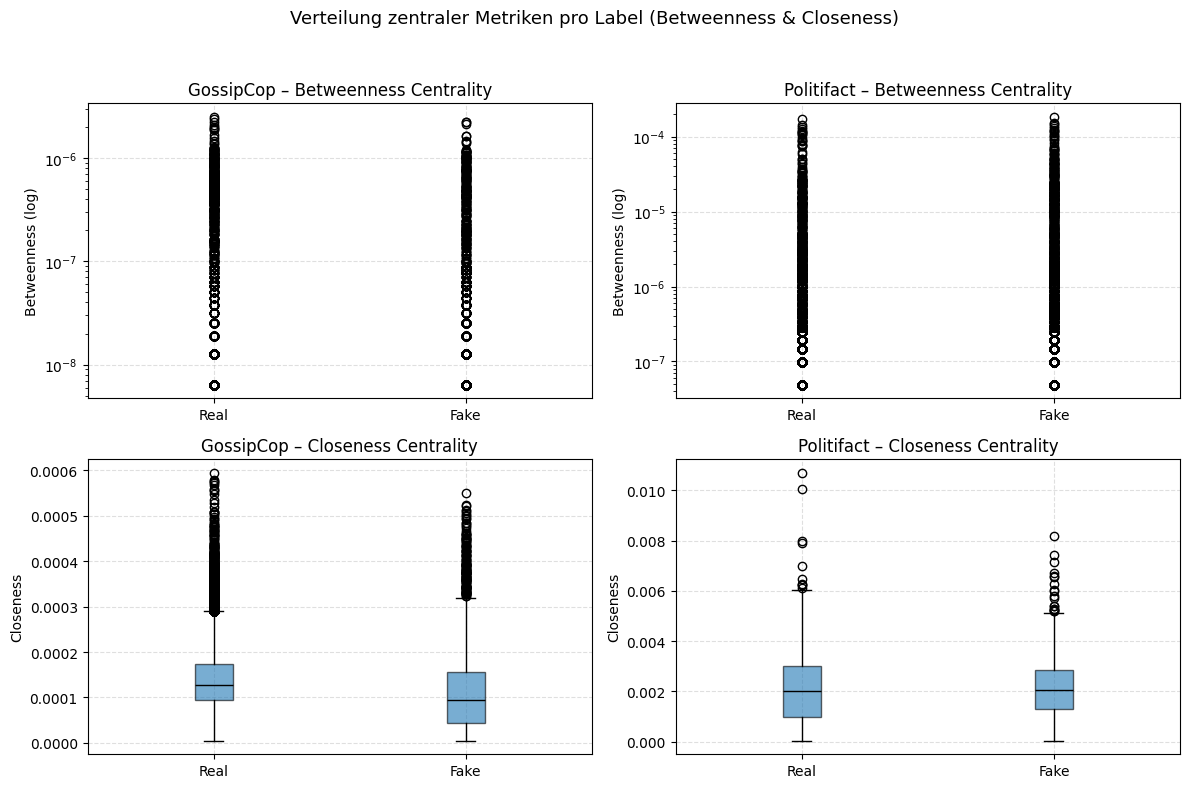

In [ ]:
# Funktion - Berechnung zentraler Metriken pro Knoten
def compute_centralities(edges, node_graph_id, graph_labels, name, sample_limit=5000, random_state=42):
    """
    Berechnet Betweenness und Closeness Centrality pro Knoten.
    Zufälliges Sampling zur Laufzeitreduktion.
    """
    G = nx.Graph()
    G.add_edges_from(edges)

    all_nodes = list(G.nodes())
    np.random.seed(random_state)
    if len(all_nodes) > sample_limit:
        nodes_sample = np.random.choice(all_nodes, size=sample_limit, replace=False)
    else:
        nodes_sample = all_nodes

    # Zentralitätsmetriken
    betweenness = nx.betweenness_centrality(G, k=min(len(nodes_sample), 500), normalized=True)
    closeness = nx.closeness_centrality(G)

    df_nodes = pd.DataFrame({
        "node_id": list(betweenness.keys()),
        "betweenness": list(betweenness.values()),
        "closeness": [closeness[n] for n in betweenness.keys()],
        "graph_id": node_graph_id[list(betweenness.keys())]
    })

    df_nodes["label"] = graph_labels[df_nodes["graph_id"]].astype(int)
    df_nodes["source"] = name

    return df_nodes


central_gos = compute_centralities(edges_gos, node_graph_id_gos, graph_labels_gos, "GossipCop")
central_pol = compute_centralities(edges_pol, node_graph_id_pol, graph_labels_pol, "Politifact")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle("Verteilung zentraler Metriken pro Label (Betweenness & Closeness)", fontsize=13)

colors = {0: "dodgerblue", 1: "firebrick"}

# Betweeness
for ax, df, title in [
    (axes[0, 0], central_gos, "GossipCop – Betweenness Centrality"),
    (axes[0, 1], central_pol, "Politifact – Betweenness Centrality"),
]:
    data = [df[df["label"] == 0]["betweenness"], df[df["label"] == 1]["betweenness"]]
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(alpha=0.6),
               medianprops=dict(color="black"))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Real", "Fake"])
    ax.set_title(title)
    ax.set_ylabel("Betweenness (log)")
    ax.set_yscale("log")  # log
    ax.grid(True, linestyle="--", alpha=0.4)


# Closeness
for ax, df, title in [
    (axes[1, 0], central_gos, "GossipCop – Closeness Centrality"),
    (axes[1, 1], central_pol, "Politifact – Closeness Centrality"),
]:
    data = [df[df["label"] == 0]["closeness"], df[df["label"] == 1]["closeness"]]
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(alpha=0.6),
               medianprops=dict(color="black"))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Real", "Fake"])
    ax.set_title(title)
    ax.set_ylabel("Closeness")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Die Boxplots zeigen die Verteilung der zentralen Netzwerkmetriken Betweenness und Closeness Centrality getrennt nach Real- und Fake-News.  
In beiden Datensätzen ist die Betweenness überwiegend sehr niedrig, weist jedoch bei Fake-News einige extreme Ausreißer auf - ein Hinweis darauf, dass dort einzelne Knoten (z.B. koordinierte Accounts oder Influencer) überproportional als Vermittler fungieren.
Die Closeness-Werte sind bei Real-News tendenziell etwas höher, was auf eine gleichmäßigere, dichtere Kommunikationsstruktur hindeutet, während Fake-News-Netzwerke stärker hierarchisch geprägt sind.
Insgesamt spricht die höhere Varianz bei Fake-News für eine zentralisierte Informationsverteilung durch wenige dominante Akteure.

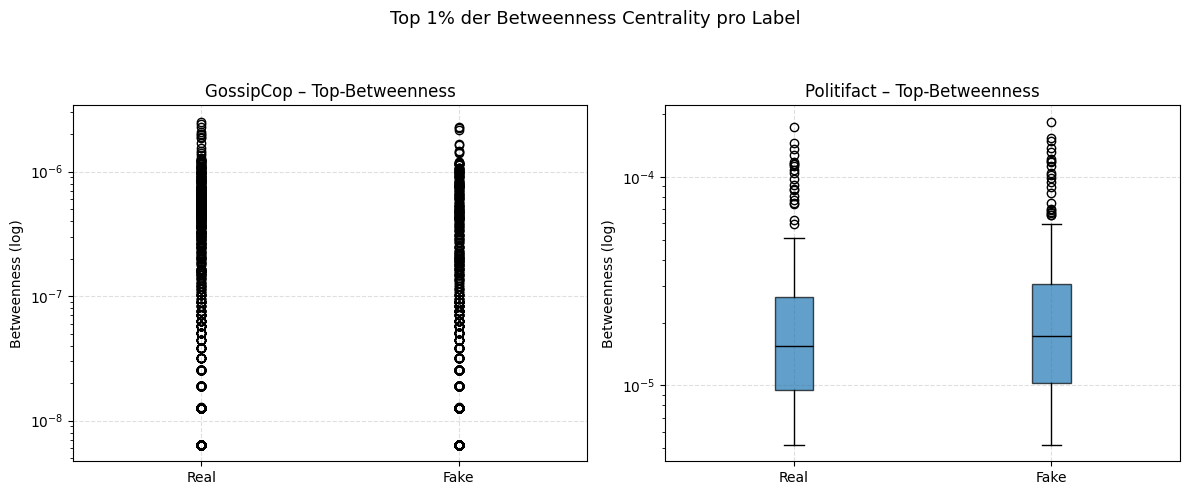

In [31]:
def select_top_percent(df, col, percent=0.01):
    threshold = df[col].quantile(1 - percent)
    return df[df[col] >= threshold]

# Top 1%
top_gos = select_top_percent(central_gos, "betweenness")
top_pol = select_top_percent(central_pol, "betweenness")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle("Top 1% der Betweenness Centrality pro Label", fontsize=13)

for ax, df, title in [
    (axes[0], top_gos, "GossipCop – Top-Betweenness"),
    (axes[1], top_pol, "Politifact – Top-Betweenness")
]:
    data = [df[df["label"] == 0]["betweenness"], df[df["label"] == 1]["betweenness"]]
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(alpha=0.7),
               medianprops=dict(color="black"))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Real", "Fake"])
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Betweenness (log)")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

In GossipCop liegen die höchsten Betweenness-Werte insgesamt sehr niedrig und unterscheiden sich kaum zwischen Real- und Fake-News. Das deutet auf lokale, wenig vernetzte Diskussionsstrukturen hin, ohne zentrale Vermittlerknoten.  
In Politifact sind die Top-Betweenness-Werte deutlich höher, d.h. die Verbreitung wird hier stärker über wenige zentrale Gatekeeper getragen. Die etwas größere Streuung bei Fake-News weist zudem auf variablere und potenziell strategische Diffusionsmuster hin.

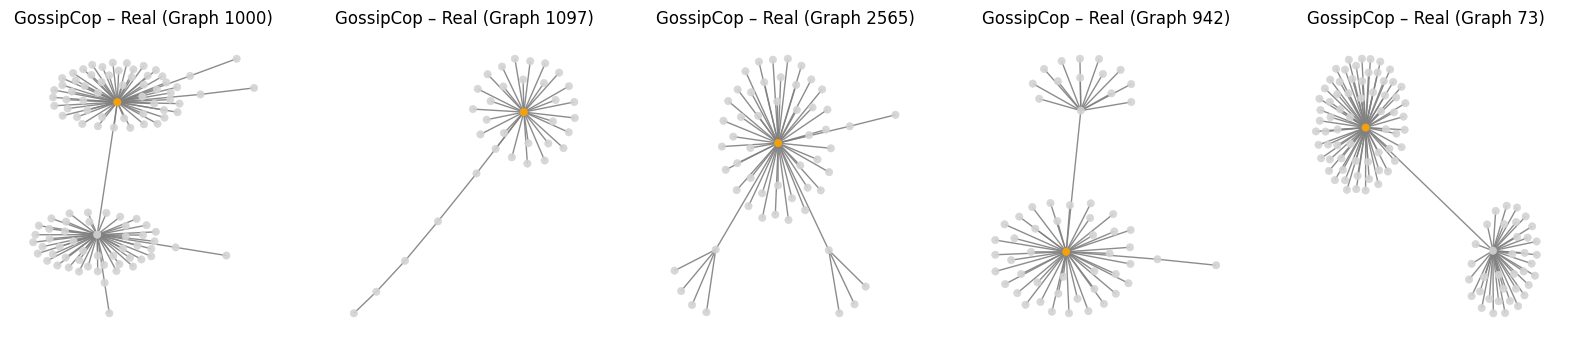

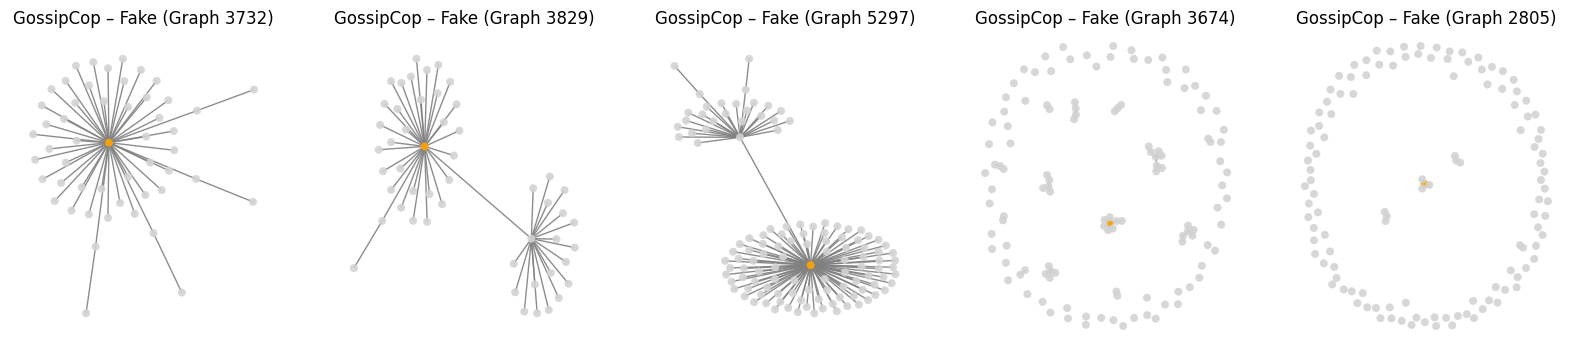

In [32]:
def sample_and_plot_with_root(edges, node_graph_id, graph_labels, label, title_prefix, 
                              n_examples=5, max_nodes=120, root_color="orange"):
    np.random.seed(42)

    graph_ids = np.where(graph_labels == label)[0]
    graph_ids = np.random.choice(graph_ids, size=n_examples, replace=False)
    

    fig, axes = plt.subplots(1, n_examples, figsize=(4*n_examples, 4))

    for ax, g_id in zip(axes, graph_ids):
        # Teilgraph
        nodes = np.where(node_graph_id == g_id)[0]
        edges_sub = edges[np.isin(edges[:, 0], nodes) & np.isin(edges[:, 1], nodes)]

        G = nx.Graph()
        G.add_edges_from(edges_sub)

        # Falls Graph zu groß- zufälliges Sampling
        if G.number_of_nodes() > max_nodes:
            nodes_sample = np.random.choice(list(G.nodes()), size=max_nodes, replace=False)
            G = G.subgraph(nodes_sample)

        # Root Node (höchster Degree)
        degrees = dict(G.degree())
        root_node = max(degrees, key=degrees.get)

        node_colors = ["lightgray" if n != root_node else root_color for n in G.nodes()]

        pos = nx.spring_layout(G, seed=42)
        ax.set_title(f"{title_prefix} (Graph {g_id})")
        ax.axis("off")
        nx.draw(G, pos, ax=ax, node_size=28, node_color=node_colors, 
                edge_color="gray", linewidths=0.4, alpha=0.9)

    plt.show()


sample_and_plot_with_root(edges_gos, node_graph_id_gos, graph_labels_gos,
                          label=0, title_prefix="GossipCop – Real", root_color="orange")

sample_and_plot_with_root(edges_gos, node_graph_id_gos, graph_labels_gos,
                          label=1, title_prefix="GossipCop – Fake", root_color="orange")


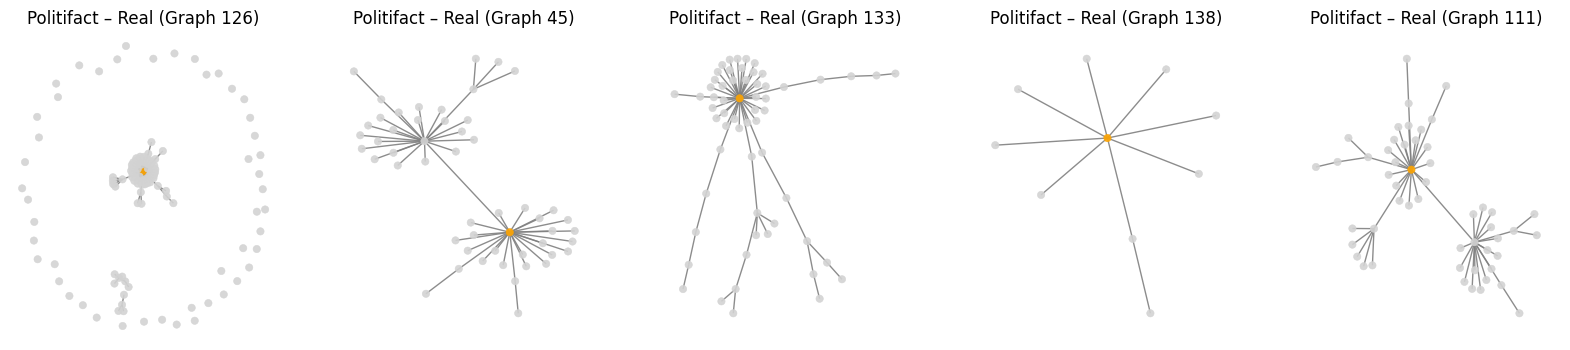

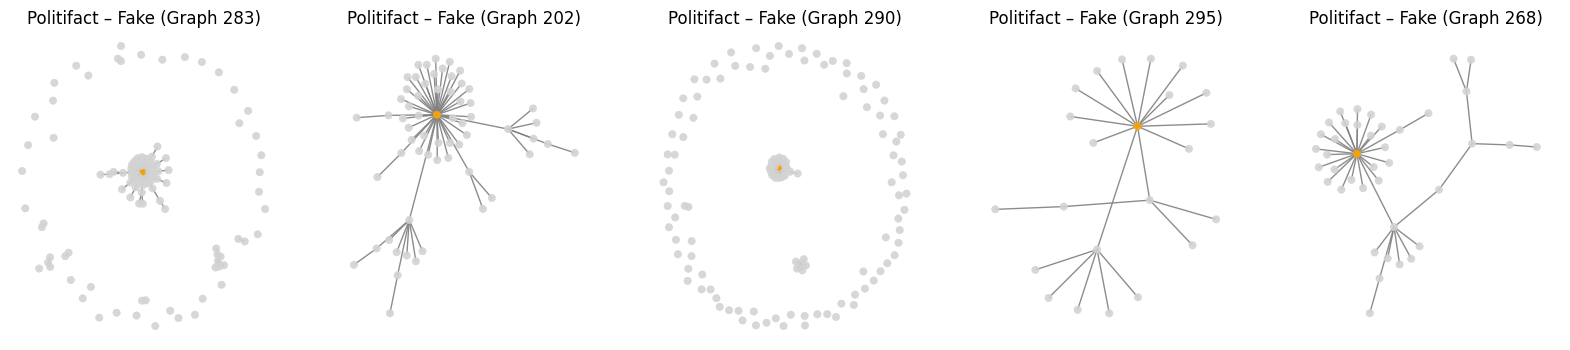

In [33]:
sample_and_plot_with_root(edges_pol, node_graph_id_pol, graph_labels_pol,
                          label=0, title_prefix="Politifact – Real", root_color="orange")

sample_and_plot_with_root(edges_pol, node_graph_id_pol, graph_labels_pol,
                          label=1, title_prefix="Politifact – Fake", root_color="orange")

Die visuellen Netzwerkgrafiken zeigen sowohl bei echten als auch bei gefälschten Nachrichten ähnliche Grundstrukturen. Eine rein visuelle Unterscheidung ist daher nicht zuverlässig möglich.  
In den aggregierten Netzwerkmetriken lassen sich jedoch leichte, jedoch konsistente strukturelle Unterschiede identifizieren (z.B. in Degree-Verteilungen, Anzahl dominanter Knoten und Netzwerkdichte). Diese Unterschiede sind zu subtil, um in einzelnen Graphvisualisierungen klar hervorzutreten, werden jedoch in der quantitativen Analyse über viele Graphen hinweg sichtbar.  